# IR-SR Model Comparison — light-SwinIR vs SPAN vs DifIISR
### One frozen protocol · same FLIR images · same detector · declared gates

**What this notebook produces.** Table L (published numbers, context only) and Table E (everything measured
here), plus every figure in `presentation_assets/`. Sources compared:
`LR native` / `bicubic (floor)` / `light-SwinIR (ours, FLIR-trained)` / `SPAN (off-the-shelf)` /
`DifIISR (off-the-shelf, task-oriented)` / `HR (ceiling)`.

---
## Important operating notes

1. **Run in order, top to bottom.** Variables live in RAM. After any session restart you must re-run from
   cell 1.1 — the expensive artifacts (SR images, YOLO predictions) are cached on Drive, so a full re-run
   is ~15–25 min, but the in-memory tables (`METRICS`, `PRED`, `SOURCES`, `map_eval`) are rebuilt every time.
2. **Section 11 is OPTIONAL** and must run only *after* 8.3. It is a sensitivity analysis, not the protocol.
3. **The frozen COCO detector is the declared protocol** (deviation #4). The thermal detector in Section 11
   is a control. **Do not swap them in the main tables** — that is moving the goalposts the gates exist to prevent.
4. **LISN is literature-only.** No public weights exist and the released code builds a different architecture
   than the paper describes. It appears in Table L with that caveat and never in Table E.
5. If a cell fails with `NameError`, you skipped a cell. The dependency order is
   `2.1 → 2.2 → 4.1 → 5.1/5.2/5.3 → 6.1 → 6.3 → 8.1 → 8.2 → 8.3`.

---
## Declared protocol deviations (say these out loud; don't hide them)
1. **Zero-training for external models** — off-the-shelf generality vs domain-matched training *is* the variable under study.
2. **DifIISR runs on a declared, seeded 300-image subset** (diffusion cost). Head-to-head tables are recomputed on that common subset for *all* sources.
3. **SPAN is RGB-trained** → grayscale by channel-replication in / channel-mean out (mathematically exact for gray input).
4. **Detector is frozen COCO-pretrained YOLOv8n** (zero-training budget), unlike DifIISR's fine-tuned detector.
5. **All LR are clean bicubic ×4** — SPAN's exact training degradation, so no degradation-mismatch unfairness.

## Validation gates — declared BEFORE the run
| # | Check | Expected (shape, not decimals) |
|---|---|---|
| G1 | Provenance | our ckpt == CONFIG (128/8); SPAN config sniffed from weights and printed |
| G2 | Data integrity | HR count == LR count; 300-subset manifest seeded and saved; zero train∩test overlap |
| G3 | Fidelity sanity | every learned SR ≥ bicubic in PSNR; LPIPS(DifIISR) ≤ LPIPS(bicubic) |
| G4 | Detection ordering | bicubic < best-SR < HR; LR-native ≤ bicubic |
| G5 | Headline | ≥1 SR source closes ≳25% of the bicubic→HR gap; PSNR↔mAP dissociation checked for DifIISR |
| G6 | Coverage | every expected figure/CSV/JSON exists in Drive assets — zero tolerance |

## Data pipeline (one image)
```
HR 640×512  ──×4 downsample──►  LR 160×128  ──┬── bicubic upscale ──►  BIC 640×512   (floor)
   │                                          ├── light-SwinIR ─────►  SR   640×512
   │                                          ├── SPAN ─────────────►  SRSPAN
   │                                          └── DifIISR ──────────►  SRDIF
   └───────────────── reference for PSNR / SSIM / LPIPS, and GT frame for mAP ─────────────────
```


In [1]:
#@title 1.1 - Environment check
import torch, platform
print(f"PyTorch {torch.__version__} | Python {platform.python_version()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} ({p.total_memory/1e9:.1f} GB)")
    DEVICE = 'cuda'
else:
    print("WARNING: no GPU — Runtime > Change runtime type > T4 GPU"); DEVICE = 'cpu'


PyTorch 2.11.0+cu128 | Python 3.12.13
GPU: Tesla T4 (15.6 GB)


In [2]:
#@title 1.2 - Dependencies
# Installs only what is missing. A fresh Colab image already has most of these.
# IMPORTANT: if Colab shows a "RESTART SESSION" prompt after this cell, the kernel was
# restarted and every variable was discarded. Run All again from cell 1.1 - the installs
# become no-ops the second time, so nothing is repeated.
import importlib, subprocess, sys

_needed = {'skimage': 'scikit-image', 'cv2': 'opencv-python-headless', 'ultralytics': 'ultralytics',
           'pandas': 'pandas', 'matplotlib': 'matplotlib', 'pycocotools': 'pycocotools',
           'lpips': 'lpips', 'gdown': 'gdown', 'psutil': 'psutil', 'pynvml': 'pynvml'}
_missing = []
for mod, pkg in _needed.items():
    try: importlib.import_module(mod)
    except ImportError: _missing.append(pkg)

if _missing:
    print("installing:", " ".join(_missing))
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *_missing], check=False)
    print("\nInstall finished. If Colab displays a RESTART SESSION button, press it and then "
          "Run All again from cell 1.1.")
else:
    print("all dependencies present")


installing: ultralytics lpips

Install finished. If Colab displays a RESTART SESSION button, press it and then Run All again from cell 1.1.


In [3]:
#@title 2.1 - Configuration
import os, sys, json, glob, time, random, hashlib, shutil
import numpy as np, torch

DEBUG_SUBSET = False          # True: run on 24 images for a pipeline check

CONFIG = {
    # Local model architecture (validated against checkpoint in 4.2)
    'scale': 4, 'embed_dim': 128, 'num_lisb': 8,
    # Evaluation protocol
    'border': 4, 'seed': 123,
    'difiisr_n': 300,                     # DifIISR evaluation subset size
    'resource_bench_n': 50,               # Images used for the resource benchmark
    'lpips_net': 'alex',
    # Detection settings
    'conf_pred': 0.001, 'conf_f1': 0.25, 'iou_f1': 0.5, 'n_boot': 1000,
    'yolo_classes': [0, 1, 2, 16],        # COCO: person, bicycle, car, dog
    'class_names': ['person', 'bicycle', 'car', 'dog'],
}
CFG_HASH = hashlib.sha1(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:8]
print(f"CFG_HASH = {CFG_HASH}  (cache key; changing CONFIG invalidates prior caches)")

random.seed(CONFIG['seed']); np.random.seed(CONFIG['seed']); torch.manual_seed(CONFIG['seed'])

def atomic_write_json(obj, path):
    tmp = path + '.tmp'
    with open(tmp, 'w') as f: json.dump(obj, f, indent=1, default=float)
    os.replace(tmp, path)

def atomic_copy(src, dst):
    tmp = dst + '.tmp'; shutil.copy2(src, tmp); os.replace(tmp, dst)

def require(*names):
    """Abort with an actionable message when a prerequisite cell has not been run."""
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(
            f"Missing prerequisites: {missing}. Run the earlier cells in order. "
            f"Dependency chain: 1.1 -> 1.2 -> 2.1 -> 2.2 -> 4.1 -> 5.1/5.2/5.3 -> 6.1 -> 6.3 -> "
            f"8.1 -> 8.2 -> 8.3 -> 9.x. After any session restart, start again at 1.1.")

RESULTS = {'config': CONFIG, 'cfg_hash': CFG_HASH, 'gates': {}}

# Expected output artifacts (checked by G6)
EXPECTED_ASSETS = [
    'tableL_literature.csv', 'tableL_literature.png',
    'subset300_manifest.json',
    'tableE_full.csv', 'tableE_full.png',
    'tableE_common300.csv', 'tableE_common300.png',
    'fig_map_vs_logtime.png', 'fig_gap_closure.png',
    'fig_fidelity_vs_perceptual.png', 'fig_resources.png',
    'fig_best_worst_SWINIR.png', 'fig_best_worst_SPAN.png',
    'best_worst_index.json',
    'fig_qualitative_5way.png',
    'results_comparison.json',
]  # fig_best_worst_DIFIISR.png is appended if DifIISR is available


CFG_HASH = 97b7c337  (cache key; changing CONFIG invalidates prior caches)


In [4]:
#@title 2.2 - Storage paths and imports
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    _cands = ['/content/drive/MyDrive/LISN', '/content/drive/MyDrive/LISN_Project']
    DRIVE_ROOT = next((c for c in _cands if os.path.exists(c)), _cands[0])
    STAGE = '/content/stage'   # Local SSD; Drive throughput is inadequate for many small files
else:
    DRIVE_ROOT = os.environ.get('LISN_ROOT', './LISN_Project'); STAGE = './stage'
print(f"DRIVE_ROOT = {DRIVE_ROOT}")

P = {
    'repo':       f"{DRIVE_ROOT}/repo",
    'flir':       f"{DRIVE_ROOT}/datasets/flir_adas/FLIR_ADAS_1_3",
    'test_hr':    f"{DRIVE_ROOT}/datasets/IR_SR/test/HR",
    'test_lr4':   f"{DRIVE_ROOT}/datasets/IR_SR/test/LR_x4",
    'ckpt':       f"{DRIVE_ROOT}/checkpoints",
    'assets':     f"{DRIVE_ROOT}/presentation_assets",
    # comparison-specific
    'ext':        f"{DRIVE_ROOT}/external",                    # SPAN / DifIISR live here (persist across sessions)
    'span_dir':   f"{DRIVE_ROOT}/external/SPAN",
    'dif_repo':   f"{DRIVE_ROOT}/external/DifIISR",
    'sr_swinir':  f"{DRIVE_ROOT}/datasets/IR_SR/test/SR_x4_{CFG_HASH}",       # Local model output
    'sr_span':    f"{DRIVE_ROOT}/datasets/IR_SR/test/SRSPAN_x4_{CFG_HASH}",
    'sr_dif':     f"{DRIVE_ROOT}/datasets/IR_SR/test/SRDIF_x4_{CFG_HASH}",
    'cache':      f"{DRIVE_ROOT}/cache_compare_{CFG_HASH}",
}
for k in ['ext','sr_swinir','sr_span','sr_dif','cache','assets']: os.makedirs(P[k], exist_ok=True)
os.makedirs(STAGE, exist_ok=True)
sys.path.insert(0, P['repo'])
from models.lisn import build_lisn                 # Model builder (repository retains the original module name)
from utils.metrics import compute_psnr_ssim        # Grayscale PSNR/SSIM with border crop
import cv2, matplotlib, matplotlib.pyplot as plt
from IPython.display import display

def save_and_show(fig, name):
    """Display a figure inline and persist it to the assets directory."""
    path = f"{P['assets']}/{name}"
    fig.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()            # display in the notebook output
    plt.close(fig)
    print(f"  saved -> {path}")

for name, path in [('repo', f"{P['repo']}/models/lisn.py"), ('test HR', P['test_hr']),
                   ('test LR', P['test_lr4']), ('ckpts', P['ckpt'])]:
    print(f"  {'OK ' if os.path.exists(path) else 'MISSING'} {name}: {path}")


Mounted at /content/drive
DRIVE_ROOT = /content/drive/MyDrive/LISN_Project
  OK  repo: /content/drive/MyDrive/LISN_Project/repo/models/lisn.py
  OK  test HR: /content/drive/MyDrive/LISN_Project/datasets/IR_SR/test/HR
  OK  test LR: /content/drive/MyDrive/LISN_Project/datasets/IR_SR/test/LR_x4
  OK  ckpts: /content/drive/MyDrive/LISN_Project/checkpoints


## Section 3 - Table L: published results

Figures reported in the source publications, each on its own dataset and protocol. The `comparable_to_TableE` column is uniformly negative by design: cross-paper comparison is not valid here. LISN appears only in this table, since no public weights exist and the released code implements a different block structure from the one described in the paper.


,model,venue,dataset,scale,params_K,PSNR_dB,SSIM,notes,comparable_to_TableE
0,LISN,ICIC 2024 (arXiv:2405.10561),CVC-09-1K,x4,279,39.70,0.9317,6000 epochs; no public weights; repo code buil...,No (different data/protocol)
1,SwinIR,ICCVW 2021,CVC-09-1K (as reported in LISN paper),x4,897,39.58,0.9309,heavyweight baseline in LISN Table 1,No (different data/protocol)
2,SPAN,CVPRW/NTIRE 2024,DIV2K_LSDIR test,x4,NTIRE-tier,27.09,NaN,1st place NTIRE-2024 ESR (overall + runtime); ...,No (different data/protocol)
3,DifIISR,CVPR 2025,authors' IR benchmarks,x4,diffusion,NaN,NaN,task-oriented (detection/segmentation guidance...,No (different data/protocol)
4,light-SwinIR (ours),this project,"FLIR ADAS val (1,366)",x4,None,28.40,NaN,500/6000-epoch budget; +2.1 dB over 26.28 dB b...,measured — see Table E


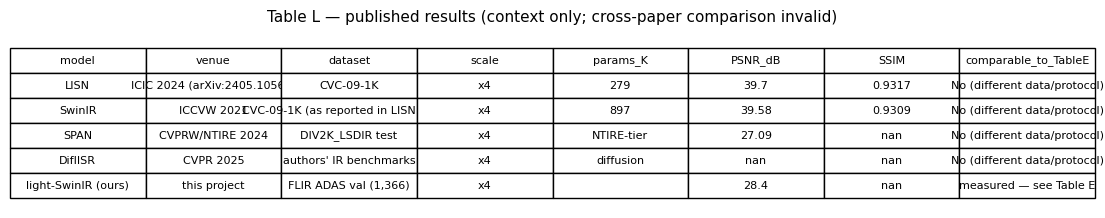

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/tableL_literature.png


In [5]:
#@title 3.1 - Table L: published results
import pandas as pd
TABLE_L = pd.DataFrame([
 # model, venue, dataset, scale, params(K), PSNR, SSIM, notes
 ['LISN',        'ICIC 2024 (arXiv:2405.10561)', 'CVC-09-1K', 'x4', 279,  39.70, 0.9317, '6000 epochs; no public weights; repo code builds Swin-style SRB, not LISB'],
 ['SwinIR',      'ICCVW 2021',                   'CVC-09-1K (as reported in LISN paper)', 'x4', 897, 39.58, 0.9309, 'heavyweight baseline in LISN Table 1'],
 ['SPAN',        'CVPRW/NTIRE 2024',             'DIV2K_LSDIR test', 'x4', 'NTIRE-tier', 27.09, None, '1st place NTIRE-2024 ESR (overall + runtime); RGB natural images'],
 ['DifIISR',     'CVPR 2025',                    'authors\' IR benchmarks', 'x4', 'diffusion', None, None, 'task-oriented (detection/segmentation guidance); perceptual metrics emphasized'],
 ['light-SwinIR (ours)', 'this project',         'FLIR ADAS val (1,366)', 'x4', None, 28.40, None, '500/6000-epoch budget; +2.1 dB over 26.28 dB bicubic floor'],
], columns=['model','venue','dataset','scale','params_K','PSNR_dB','SSIM','notes'])
TABLE_L['comparable_to_TableE'] = 'No (different data/protocol)'
TABLE_L.loc[TABLE_L.model.str.contains('ours'), 'comparable_to_TableE'] = 'measured — see Table E'
TABLE_L.to_csv(f"{P['assets']}/tableL_literature.csv", index=False)
display(TABLE_L)

fig, ax = plt.subplots(figsize=(14, 2.2)); ax.axis('off')
t = ax.table(cellText=TABLE_L.drop(columns=['notes']).values,
             colLabels=TABLE_L.drop(columns=['notes']).columns, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1, 1.5)
ax.set_title('Table L — published results (context only; cross-paper comparison invalid)', fontsize=11, pad=12)
save_and_show(fig, 'tableL_literature.png')
RESULTS['table_L'] = TABLE_L.to_dict('records')


## Section 4 - Test-set staging and evaluation subset

The test set is copied to local storage, and the DifIISR evaluation subset is drawn once with a fixed seed. The manifest is written to disk before any inference is run, so the subset is fixed independently of the results.


In [6]:
#@title 4.1 - Stage test set and draw evaluation subset
require('P', 'STAGE', 'CONFIG')
hr_stems = sorted(os.path.splitext(f)[0] for f in os.listdir(P['test_hr']) if f.endswith('.png'))
lr_stems = sorted(os.path.splitext(f)[0] for f in os.listdir(P['test_lr4']) if f.endswith('.png'))
assert hr_stems == lr_stems, f"HR/LR mismatch: {len(hr_stems)} vs {len(lr_stems)}"
TEST_STEMS = hr_stems[:24] if DEBUG_SUBSET else hr_stems
print(f"test set: {len(TEST_STEMS)} images (DEBUG_SUBSET={DEBUG_SUBSET})")

for sub in ['HR', 'LR', 'SR', 'SRSPAN', 'SRDIF', 'BIC']: os.makedirs(f"{STAGE}/{sub}", exist_ok=True)
n_copied = 0
for s in TEST_STEMS:
    for sub, src_dir in [('HR', P['test_hr']), ('LR', P['test_lr4'])]:
        dst = f"{STAGE}/{sub}/{s}.png"
        if not os.path.exists(dst): shutil.copy2(f"{src_dir}/{s}.png", dst); n_copied += 1
print(f"staged ({n_copied} new copies)")

# Evaluation subset: seeded draw, manifest written before any inference
manifest_path = f"{P['assets']}/subset300_manifest.json"
_want_n = min(CONFIG['difiisr_n'], len(TEST_STEMS))
_m = json.load(open(manifest_path)) if os.path.exists(manifest_path) else None
if _m and _m.get('n') == _want_n:
    SUB300 = _m['stems']
    print(f"subset manifest reused ({len(SUB300)} stems)")
else:
    if _m: print(f"manifest n={_m.get('n')} != wanted {_want_n} - redrawing with seed and overwriting")
    rng = random.Random(CONFIG['seed'])
    n = min(CONFIG['difiisr_n'], len(TEST_STEMS))
    SUB300 = sorted(rng.sample(TEST_STEMS, n))
    atomic_write_json({'seed': CONFIG['seed'], 'n': n, 'drawn_from': len(TEST_STEMS),
                       'date': time.strftime('%Y-%m-%d'), 'stems': SUB300}, manifest_path)
    print(f"subset manifest written: {n} stems, seed={CONFIG['seed']}")
SUB300 = [s for s in SUB300 if s in set(TEST_STEMS)]   # Restrict to stems present in this run
RESULTS['gates']['G2_data'] = {'n_test': len(TEST_STEMS), 'n_sub300': len(SUB300), 'hr_eq_lr': True}


test set: 1366 images (DEBUG_SUBSET=False)
staged (2732 new copies)
subset manifest reused (300 stems)


In [7]:
#@title 4.2 - Checkpoint provenance: local model (G1)
require('P', 'CONFIG')
import pandas as pd
def sniff_ours(sd):
    embed = sd['sfe.weight'].shape[0]
    n_blk = len({k.split('.')[1] for k in sd if k.startswith('dfe.')})
    scale = int(round((sd['iir_conv.weight'].shape[0]) ** 0.5))
    return embed, n_blk, scale, int(sum(v.numel() for v in sd.values()))

rows = []
for f in sorted(glob.glob(f"{P['ckpt']}/lisn_*.pth")):
    ck = torch.load(f, map_location='cpu', weights_only=True)
    sd = ck['model'] if isinstance(ck, dict) and 'model' in ck else ck
    e, n, s, prm = sniff_ours(sd)
    rows.append({'file': os.path.basename(f), 'embed': e, 'blocks': n, 'scale': s,
                 'params': prm, 'match': (e, n, s) == (CONFIG['embed_dim'], CONFIG['num_lisb'], CONFIG['scale'])})
prov = pd.DataFrame(rows); display(prov)
matches = prov[prov.match]
assert len(matches) > 0, "No checkpoint matches CONFIG"
_best = f"{P['ckpt']}/lisn_best.pth"
BEST_CKPT = _best if (os.path.exists(_best) and matches.file.eq('lisn_best.pth').any()) \
            else f"{P['ckpt']}/{matches.iloc[-1].file}"
print(f"BEST_CKPT = {os.path.basename(BEST_CKPT)}")
RESULTS['gates']['G1_provenance'] = {'ours': os.path.basename(BEST_CKPT), 'ours_ok': True}


,file,embed,blocks,scale,params,match
0,lisn_best.pth,128,8,4,658576,True
1,lisn_epoch_0020.pth,128,8,4,658576,True
2,lisn_epoch_0040.pth,128,8,4,658576,True
3,lisn_epoch_0060.pth,128,8,4,658576,True
4,lisn_epoch_0080.pth,128,8,4,658576,True
5,lisn_epoch_0100.pth,128,8,4,658576,True
6,lisn_epoch_0120.pth,128,8,4,658576,True
7,lisn_epoch_0140.pth,128,8,4,658576,True
8,lisn_epoch_0160.pth,128,8,4,658576,True
9,lisn_epoch_0180.pth,128,8,4,658576,True


BEST_CKPT = lisn_best.pth


## Section 5 - External model acquisition

SPAN and DifIISR are acquired and validated on the same terms as the local checkpoint: the SPAN configuration is inferred from weight shapes and loaded with `strict=True`, so a silent partial load cannot occur. DifIISR setup is idempotent; if its weights are unavailable the notebook sets `SKIP_DIFIISR` and all remaining results still complete.


In [8]:
#@title 5.1 - SPAN: acquisition and strict load (G1)
require('P', 'CONFIG', 'DEVICE')
import subprocess, zipfile, inspect, importlib.util, types
from torch import nn

if not os.path.exists(f"{P['span_dir']}/README.md"):
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/hongyuanyu/SPAN', P['span_dir']], check=True)
print("SPAN repo ok")

SPAN_CKPT_DIR = f"{P['span_dir']}/ckpts"; os.makedirs(SPAN_CKPT_DIR, exist_ok=True)
if not glob.glob(f"{SPAN_CKPT_DIR}/**/*.pth", recursive=True):
    import gdown
    out = f"{SPAN_CKPT_DIR}/span_ckpts_bundle"
    gdown.download(id='1iYUA2TzKuxI0vzmA-UXr_nB43XgPOXUg', output=out, quiet=False)
    if zipfile.is_zipfile(out):
        with zipfile.ZipFile(out) as z: z.extractall(SPAN_CKPT_DIR)
span_pths = sorted(glob.glob(f"{SPAN_CKPT_DIR}/**/*.pth", recursive=True))
assert span_pths, f"No SPAN .pth under {SPAN_CKPT_DIR}"
print(f"found {len(span_pths)} SPAN checkpoint file(s)")

# Provide a minimal basicsr.utils.registry stub; the PyPI package is incompatible with current torchvision
class _Reg:
    def register(self, obj=None, suffix=None):
        return obj if obj is not None else (lambda cls: cls)
_b, _u, _r = types.ModuleType('basicsr'), types.ModuleType('basicsr.utils'), types.ModuleType('basicsr.utils.registry')
_r.ARCH_REGISTRY = _Reg(); _u.registry = _r; _b.utils = _u
sys.modules.update({'basicsr': _b, 'basicsr.utils': _u, 'basicsr.utils.registry': _r})

arch_cands = glob.glob(f"{P['span_dir']}/**/*span*arch*.py", recursive=True)
arch_file = next(a for a in arch_cands if 'arch' in os.path.basename(a).lower())
spec = importlib.util.spec_from_file_location('span_arch', arch_file)
span_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(span_mod)
SPAN_CLS = next(getattr(span_mod, n) for n in dir(span_mod)
                if n.lower() == 'span' and inspect.isclass(getattr(span_mod, n)))
sig = inspect.signature(SPAN_CLS.__init__)
print(f"arch: {arch_file}\nSPAN{sig}")

def sniff_span(sd):
    up = next(v for k, v in sd.items() if 'upsampler' in k and v.dim() == 4)
    scale = int(round((up.shape[0] / 3) ** 0.5))
    return scale, int(sum(v.numel() for v in sd.values()))

SPAN_NET, SPAN_INFO = None, None
for f in span_pths:
    ck = torch.load(f, map_location='cpu', weights_only=True)
    sd = ck.get('params', ck.get('params_ema', ck)) if isinstance(ck, dict) else ck
    try: scale, prm = sniff_span(sd)
    except StopIteration: continue
    if scale != CONFIG['scale']: continue
    for fc in [48, 52, 26, 28, 64]:
        try:
            kw = {'num_in_ch': 3, 'num_out_ch': 3, 'upscale': scale}
            if 'feature_channels' in sig.parameters: kw['feature_channels'] = fc
            net = SPAN_CLS(**kw)
            net.load_state_dict(sd, strict=True)          # strict=True: reject any shape or key mismatch
            SPAN_NET, SPAN_INFO = net, {'file': os.path.basename(f), 'scale': scale,
                                        'feature_channels': fc, 'params': prm}
            break
        except Exception: continue
    if SPAN_NET is not None: break
assert SPAN_NET is not None, "No SPAN x4 checkpoint strict-loaded"
print(f"SPAN loaded: {SPAN_INFO}")
RESULTS['gates'].setdefault('G1_provenance', {})['span'] = SPAN_INFO

class GrayWrap(nn.Module):
    """Replicate 1->3 in, mean 3->1 out — exact grayscale adapter (declared deviation #3)."""
    def __init__(self, net): super().__init__(); self.net = net
    def forward(self, x): return self.net(x.repeat(1, 3, 1, 1)).mean(1, keepdim=True)

span_model = GrayWrap(SPAN_NET).to(DEVICE).eval()


SPAN repo ok
found 4 SPAN checkpoint file(s)
arch: /content/drive/MyDrive/LISN_Project/external/SPAN/basicsr/archs/span_arch.py
SPAN(self, num_in_ch, num_out_ch, feature_channels=48, upscale=4, bias=True, img_range=255.0, rgb_mean=(0.4488, 0.4371, 0.404))
SPAN loaded: {'file': 'spanx4_ch48.pth', 'scale': 4, 'feature_channels': 48, 'params': 2236728}


In [9]:
#@title 5.2 - DifIISR: environment setup and readiness check
require('P', 'EXPECTED_ASSETS')
import subprocess, site

# Repository
if not os.path.exists(f"{P['dif_repo']}/inference.py"):
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/zirui0625/DifIISR', P['dif_repo']], check=True)
    print("cloned DifIISR")

# Dependencies, installed individually; torch packages are excluded to preserve the CUDA build
for line in open(f"{P['dif_repo']}/requirements.txt"):
    pkg = line.strip()
    if not pkg or pkg.startswith('#') or any(t in pkg.lower() for t in ['torch', 'torchvision', 'torchaudio']):
        continue
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], capture_output=True, text=True)
    if r.returncode != 0: print(f"  WARN (non-fatal): {pkg}")
print("deps ok")

# imgaug compatibility patch: np.sctypes was removed in NumPy 2.0
for sp in site.getsitepackages() + [site.getusersitepackages()]:
    tgt = os.path.join(sp, 'imgaug', 'imgaug.py')
    if os.path.exists(tgt):
        src = open(tgt).read()
        if 'np.sctypes' in src:
            src = (src.replace('NP_FLOAT_TYPES = set(np.sctypes["float"])',
                               'NP_FLOAT_TYPES = {np.float16, np.float32, np.float64, np.longdouble}')
                      .replace('NP_INT_TYPES = set(np.sctypes["int"])',
                               'NP_INT_TYPES = {np.int8, np.int16, np.int32, np.int64}')
                      .replace('NP_UINT_TYPES = set(np.sctypes["uint"])',
                               'NP_UINT_TYPES = {np.uint8, np.uint16, np.uint32, np.uint64}'))
            open(tgt, 'w').write(src); print(f"patched imgaug: {tgt}")
        break

# Variant entry point without the bundled evaluation step (it assumes 3-channel references)
src = open(f"{P['dif_repo']}/inference.py").read().replace(
    'evaluate.evaluate(args.output, args.reference, None)',
    '# evaluate.evaluate(...)  # disabled')
open(f"{P['dif_repo']}/inference_noval.py", 'w').write(src)

# Model weights: diffusion checkpoint and VQ autoencoder
WD = f"{P['dif_repo']}/weights"; os.makedirs(WD, exist_ok=True)
if not os.path.exists(f"{WD}/DifIISR.pth"):
    import gdown; gdown.download(id='1PhRvk1Dlp3CCrPkrxRfNbNZ3fNgviDVZ', output=f"{WD}/DifIISR.pth", quiet=False)
if not os.path.exists(f"{WD}/autoencoder_vq_f4.pth"):
    for url in ["https://github.com/zsyOAOA/ResShift/releases/download/v2.0/autoencoder_vq_f4.pth",
                "https://huggingface.co/OAOA/ResShift/resolve/main/autoencoder_vq_f4.pth"]:
        r = subprocess.run(['wget', '-q', '-O', f"{WD}/autoencoder_vq_f4.pth", url])
        if r.returncode == 0 and os.path.getsize(f"{WD}/autoencoder_vq_f4.pth") > 1_000_000: break
        if os.path.exists(f"{WD}/autoencoder_vq_f4.pth"): os.remove(f"{WD}/autoencoder_vq_f4.pth")

need = {'DifIISR.pth', 'autoencoder_vq_f4.pth'}
have = need & set(os.listdir(WD))
SKIP_DIFIISR = (have != need)
if SKIP_DIFIISR:
    print(f"DifIISR NOT ready — missing {sorted(need - have)}; place manually in {WD} and re-run this cell")
else:
    print(f"DifIISR ready: {sorted(have)}")
    if 'fig_best_worst_DIFIISR.png' not in EXPECTED_ASSETS:
        EXPECTED_ASSETS.append('fig_best_worst_DIFIISR.png')


  WARN (non-fatal): xformers==0.0.23
  WARN (non-fatal): scipy==1.9.3
deps ok
patched imgaug: /usr/local/lib/python3.12/dist-packages/imgaug/imgaug.py
DifIISR ready: ['DifIISR.pth', 'autoencoder_vq_f4.pth']


In [10]:
#@title 5.3 - Resource monitor and LPIPS metric
require('CONFIG', 'DEVICE')
import threading, psutil, lpips
try:
    import pynvml; pynvml.nvmlInit(); _NVH = pynvml.nvmlDeviceGetHandleByIndex(0)
except Exception:
    _NVH = None; print("pynvml unavailable — GPU util via torch only")

class ResourceMonitor:
    """Background sampler (5 Hz). Reports mean/max CPU%, RAM GB, GPU util%, GPU mem GB,
    plus torch peak allocated. Used around each model's dedicated benchmark pass so
    resource numbers are attributable per model (interleaved loops can't attribute)."""
    def __init__(self, tag): self.tag, self.samples, self._stop = tag, [], threading.Event()
    def _run(self):
        psutil.cpu_percent(None)
        while not self._stop.wait(0.2):
            s = {'cpu': psutil.cpu_percent(None), 'ram': psutil.virtual_memory().used / 1e9}
            if _NVH:
                u = pynvml.nvmlDeviceGetUtilizationRates(_NVH)
                m = pynvml.nvmlDeviceGetMemoryInfo(_NVH)
                s.update(gpu=u.gpu, gmem=m.used / 1e9)
            self.samples.append(s)
    def __enter__(self):
        if DEVICE == 'cuda': torch.cuda.reset_peak_memory_stats()
        self.t = threading.Thread(target=self._run, daemon=True); self.t.start(); return self
    def __exit__(self, *a):
        self._stop.set(); self.t.join()
        import numpy as _np
        def agg(k):
            v = [s[k] for s in self.samples if k in s]; return (float(_np.mean(v)), float(_np.max(v))) if v else (None, None)
        self.report = {'tag': self.tag,
                       'cpu_mean_%': agg('cpu')[0], 'cpu_max_%': agg('cpu')[1],
                       'ram_max_GB': agg('ram')[1],
                       'gpu_mean_%': agg('gpu')[0], 'gpu_max_%': agg('gpu')[1],
                       'gpu_mem_max_GB': agg('gmem')[1],
                       'torch_peak_GB': torch.cuda.max_memory_allocated() / 1e9 if DEVICE == 'cuda' else None}

LPIPS_FN = lpips.LPIPS(net=CONFIG['lpips_net']).to(DEVICE).eval()
@torch.no_grad()
def lpips_gray(a_u8, b_u8):
    def prep(u8):
        t = torch.from_numpy(u8.astype(np.float32) / 255.)[None, None].to(DEVICE)
        return (t * 2 - 1).repeat(1, 3, 1, 1)
    return float(LPIPS_FN(prep(a_u8), prep(b_u8)).item())
print("monitor + LPIPS ready")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 94.7MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
monitor + LPIPS ready


## Section 6 - Inference and fidelity metrics

All cheap-model outputs and metrics are produced in a single pass over the test set, under one border-crop protocol. Per-image PSNR, SSIM and LPIPS are retained, not only their means, since they are required for the best/worst selection and the bootstrap intervals. DifIISR is evaluated separately on the declared subset in 6.3.


In [11]:
#@title 6.1 - Inference and fidelity metrics: bicubic, light-SwinIR, SPAN
require('TEST_STEMS', 'STAGE', 'span_model', 'lpips_gray', 'BEST_CKPT')
model = build_lisn(upscale=CONFIG['scale'], embed_dim=CONFIG['embed_dim'], num_lisb=CONFIG['num_lisb']).to(DEVICE)
ck = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=True)
model.load_state_dict(ck['model'] if 'model' in ck else ck); model.eval()
N_PARAMS = {'SWINIR': sum(p.numel() for p in model.parameters()),
            'SPAN':   sum(p.numel() for p in SPAN_NET.parameters())}
print({k: f"{v/1e3:.0f}K" for k, v in N_PARAMS.items()})

@torch.no_grad()
def run_net(net, lr_u8):
    x = torch.from_numpy(lr_u8.astype(np.float32) / 255.)[None, None].to(DEVICE)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter(); y = net(x)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) * 1e3
    sr = (y.clamp(0, 1)[0, 0].cpu().numpy() * 255).round().astype(np.uint8)
    return sr, ms

marker = f"{P['cache']}/.pass1_{len(TEST_STEMS)}"
recs, T = [], {'SWINIR': [], 'SPAN': []}
for i, s in enumerate(TEST_STEMS):
    hr = cv2.imread(f"{STAGE}/HR/{s}.png", cv2.IMREAD_GRAYSCALE)
    lr = cv2.imread(f"{STAGE}/LR/{s}.png", cv2.IMREAD_GRAYSCALE)
    bic = cv2.resize(lr, (hr.shape[1], hr.shape[0]), interpolation=cv2.INTER_CUBIC)
    cv2.imwrite(f"{STAGE}/BIC/{s}.png", bic)
    outs = {'BIC': bic}
    for tag, net, folder in [('SWINIR', model, 'SR'), ('SPAN', span_model, 'SRSPAN')]:
        pth = f"{STAGE}/{folder}/{s}.png"
        if os.path.exists(pth) and os.path.exists(marker):
            outs[tag] = cv2.imread(pth, cv2.IMREAD_GRAYSCALE)
        else:
            outs[tag], ms = run_net(net, lr); T[tag].append(ms); cv2.imwrite(pth, outs[tag])
    for tag, img in outs.items():
        ps, ss = compute_psnr_ssim(img, hr, border=CONFIG['border'])
        recs.append({'stem': s, 'source': tag, 'psnr': ps, 'ssim': ss, 'lpips': lpips_gray(img, hr)})
    if (i + 1) % 100 == 0: print(f"  {i+1}/{len(TEST_STEMS)}")
open(marker, 'w').close()

import pandas as pd
METRICS = pd.DataFrame(recs)
TIMING = {k: float(np.median(v)) for k, v in T.items() if v}
atomic_write_json({'metrics': METRICS.to_dict('records'), 'timing_ms': TIMING},
                  f"{P['cache']}/pass1_metrics.json")
# write SR outputs back to Drive once (atomic), for the YOLO stage + persistence
for folder, drv in [('SR', P['sr_swinir']), ('SRSPAN', P['sr_span'])]:
    for s in TEST_STEMS: atomic_copy(f"{STAGE}/{folder}/{s}.png", f"{drv}/{s}.png")
print(METRICS.groupby('source')[['psnr', 'ssim', 'lpips']].mean().round(4))
print("median ms/img:", {k: round(v, 1) for k, v in TIMING.items()})


{'SWINIR': '659K', 'SPAN': '2237K'}
  100/1366
  200/1366
  300/1366
  400/1366
  500/1366
  600/1366
  700/1366
  800/1366
  900/1366
  1000/1366
  1100/1366
  1200/1366
  1300/1366
           psnr    ssim   lpips
source                         
BIC     28.0027  0.6866  0.5323
SPAN    24.9965  0.6254  0.4996
SWINIR  28.6042  0.7069  0.2594
median ms/img: {'SWINIR': 36.6, 'SPAN': 16.2}


In [12]:
#@title 6.2 - Per-model resource benchmark
require('TEST_STEMS', 'model', 'span_model', 'ResourceMonitor')
BENCH = TEST_STEMS[:CONFIG['resource_bench_n']]
RES_REPORTS = []
for tag, net in [('SWINIR', model), ('SPAN', span_model)]:
    with ResourceMonitor(tag) as m:
        for s in BENCH:
            lr = cv2.imread(f"{STAGE}/LR/{s}.png", cv2.IMREAD_GRAYSCALE); run_net(net, lr)
    RES_REPORTS.append(m.report)
pd_res = pd.DataFrame(RES_REPORTS).set_index('tag'); display(pd_res.round(2))
RESULTS['resources'] = RES_REPORTS


,cpu_mean_%,cpu_max_%,ram_max_GB,gpu_mean_%,gpu_max_%,gpu_mem_max_GB,torch_peak_GB
tag,,,,,,,
SWINIR,61.41,65.9,2.71,86.86,95.0,0.84,0.24
SPAN,53.75,60.0,2.70,54.75,89.0,0.84,0.11


In [13]:
#@title 6.3 - DifIISR inference on the evaluation subset\n# Release GPU memory before launching the DifIISR subprocess
try: del model, span_model
except NameError: pass
torch.cuda.empty_cache()
import gc; gc.collect()
print(f"GPU freed: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

DIF_TIME_MS = None
if SKIP_DIFIISR:
    print("skipped (see 5.2)")
else:
    dif_marker = f"{P['cache']}/.dif_{len(SUB300)}"
    dif_in, dif_ref, dif_out = f"{STAGE}/_dif_lr", f"{STAGE}/_dif_hr", f"{STAGE}/_dif_out"
    if not os.path.exists(dif_marker):
        for d in [dif_in, dif_ref, dif_out]:          # Clear stale contents so exactly SUB300 is processed
            if os.path.exists(d): shutil.rmtree(d)
            os.makedirs(d)
        for s in SUB300:
            shutil.copy2(f"{STAGE}/LR/{s}.png", f"{dif_in}/{s}.png")
            shutil.copy2(f"{STAGE}/HR/{s}.png", f"{dif_ref}/{s}.png")
        cmd = [sys.executable, 'inference_noval.py', '-input', dif_in, '-output', dif_out,
               '-reference', dif_ref, '--config', 'configs/DifIISR_test.yaml']
        print("running DifIISR (diffusion — expect this to take a while)...")
        t0 = time.perf_counter()
        with ResourceMonitor('DIFIISR') as m:
            r = subprocess.run(cmd, cwd=P['dif_repo'], capture_output=True, text=True)
        if r.returncode != 0:
            print("DifIISR FAILED — stderr tail:\n", r.stderr[-2000:]); SKIP_DIFIISR = True
        else:
            DIF_TIME_MS = (time.perf_counter() - t0) * 1e3 / len(SUB300)   # wall-clock time divided by image count (approximate)
            RES_REPORTS.append(m.report); RESULTS['resources'] = RES_REPORTS
            # Normalise outputs to grayscale uint8 at HR resolution
            for s in SUB300:
                cand = glob.glob(f"{dif_out}/**/{s}.*", recursive=True) or glob.glob(f"{dif_out}/**/*{s}*", recursive=True)
                assert cand, f"DifIISR output missing for {s}"
                img = cv2.imread(cand[0], cv2.IMREAD_GRAYSCALE)
                hr = cv2.imread(f"{STAGE}/HR/{s}.png", cv2.IMREAD_GRAYSCALE)
                if img.shape != hr.shape: img = cv2.resize(img, (hr.shape[1], hr.shape[0]), interpolation=cv2.INTER_CUBIC)
                cv2.imwrite(f"{STAGE}/SRDIF/{s}.png", img); atomic_copy(f"{STAGE}/SRDIF/{s}.png", f"{P['sr_dif']}/{s}.png")
            open(dif_marker, 'w').close()
    else:
        print("DifIISR outputs cached — reusing")
        for s in SUB300:
            if not os.path.exists(f"{STAGE}/SRDIF/{s}.png"): shutil.copy2(f"{P['sr_dif']}/{s}.png", f"{STAGE}/SRDIF/{s}.png")
    if not SKIP_DIFIISR:
        dif_recs = []
        for s in SUB300:
            hr = cv2.imread(f"{STAGE}/HR/{s}.png", cv2.IMREAD_GRAYSCALE)
            sr = cv2.imread(f"{STAGE}/SRDIF/{s}.png", cv2.IMREAD_GRAYSCALE)
            ps, ss = compute_psnr_ssim(sr, hr, border=CONFIG['border'])
            dif_recs.append({'stem': s, 'source': 'DIFIISR', 'psnr': ps, 'ssim': ss, 'lpips': lpips_gray(sr, hr)})
        METRICS = METRICS[METRICS.source != 'DIFIISR']     # Remove any prior DifIISR rows before appending
        METRICS = pd.concat([METRICS, pd.DataFrame(dif_recs)], ignore_index=True)
        if DIF_TIME_MS: TIMING['DIFIISR'] = float(DIF_TIME_MS)
        print(METRICS[METRICS.source == 'DIFIISR'][['psnr', 'ssim', 'lpips']].mean().round(4))
        if DIF_TIME_MS: print(f"~{DIF_TIME_MS:.0f} ms/img (wall/n, declared approximate)")


GPU freed: 0.03 GB allocated
DifIISR outputs cached — reusing
psnr     25.8412
ssim      0.5837
lpips     0.3127
dtype: float64


In [14]:
#@title 6.4 - DifIISR per-image inference time (difference method)
# Measures wall time for 1 image and for 1+K images with the same subprocess entry point,
# then reports (t_{1+K} - t_1) / K. This removes model-load and import overhead, which the
# earlier wall/n figure included. Cached SR outputs are unaffected.
require('SUB300', 'STAGE', 'TIMING', 'SKIP_DIFIISR')
DIF_TIMING_K = 10
if SKIP_DIFIISR:
    print("DifIISR unavailable; timing skipped")
else:
    timing_cache = f"{P['cache']}/difiisr_timing.json"
    if os.path.exists(timing_cache):
        _t = json.load(open(timing_cache))
        TIMING['DIFIISR'] = _t['ms_per_image']
        print(f"DifIISR timing loaded from cache: {TIMING['DIFIISR']:.0f} ms/image "
              f"(K={_t['K']}, measured {_t['date']})")
    else:
        import tempfile
        def _run_n(stems):
            din, dref, dout = [tempfile.mkdtemp(dir='/content') for _ in range(3)]
            for s in stems:
                shutil.copy2(f"{STAGE}/LR/{s}.png", f"{din}/{s}.png")
                shutil.copy2(f"{STAGE}/HR/{s}.png", f"{dref}/{s}.png")
            t0 = time.perf_counter()
            r = subprocess.run([sys.executable, 'inference_noval.py', '-input', din,
                                '-output', dout, '-reference', dref,
                                '--config', 'configs/DifIISR_test.yaml'],
                               cwd=P['dif_repo'], capture_output=True, text=True)
            dt = time.perf_counter() - t0
            for d in (din, dref, dout): shutil.rmtree(d, ignore_errors=True)
            assert r.returncode == 0, r.stderr[-1500:]
            return dt
        _ = _run_n(SUB300[:1])   # warm-up: absorb cold start (CUDA init, disk cache) before measuring
        t1  = _run_n(SUB300[:1])
        t1k = _run_n(SUB300[:1 + DIF_TIMING_K])
        ms = (t1k - t1) * 1e3 / DIF_TIMING_K
        TIMING['DIFIISR'] = float(ms)
        atomic_write_json({'ms_per_image': float(ms), 'K': DIF_TIMING_K,
                           't1_s': t1, 't1k_s': t1k, 'date': time.strftime('%Y-%m-%d')},
                          timing_cache)
        print(f"DifIISR: {ms:.0f} ms/image (load-time excluded; "
              f"t1={t1:.1f}s, t{1+DIF_TIMING_K}={t1k:.1f}s)")


DifIISR timing loaded from cache: 682 ms/image (K=10, measured 2026-08-08)


## Section 7 - Per-image galleries

Images are ranked by improvement over bicubic on the same frame, which is more informative than absolute score. Per-metric extremes are also indexed to JSON so galleries can be regenerated without repeating inference.


In [15]:
#@title 7.1 - Best/worst image index and contact sheets
require('METRICS', 'SUB300')
bic = METRICS[METRICS.source == 'BIC'].set_index('stem')
bw_index = {}
SR_SOURCES = [s for s in ['SWINIR', 'SPAN', 'DIFIISR'] if s in METRICS.source.unique()]
SRC_DIR = {'BIC': 'BIC', 'SWINIR': 'SR', 'SPAN': 'SRSPAN', 'DIFIISR': 'SRDIF'}

for src in SR_SOURCES:
    d = METRICS[METRICS.source == src].set_index('stem')
    common = d.index.intersection(bic.index)
    gain = (d.loc[common, 'psnr'] - bic.loc[common, 'psnr']).sort_values()
    bw = {'best_gain': gain.tail(3).index.tolist()[::-1], 'worst_gain': gain.head(3).index.tolist()}
    for mname, asc in [('psnr', False), ('ssim', False), ('lpips', True)]:
        srt = d[mname].sort_values(ascending=asc)
        bw[f'best_{mname}'] = srt.tail(3).index.tolist()[::-1] if not asc else srt.head(3).index.tolist()
        bw[f'worst_{mname}'] = srt.head(3).index.tolist() if not asc else srt.tail(3).index.tolist()
    bw_index[src] = bw

    stems6 = bw['best_gain'] + bw['worst_gain']
    fig, axes = plt.subplots(6, 3, figsize=(10, 17))
    for r, s in enumerate(stems6):
        row = [('Bicubic', f"{STAGE}/BIC/{s}.png", bic.loc[s]),
               (src, f"{STAGE}/{SRC_DIR[src]}/{s}.png", d.loc[s]),
               ('HR', f"{STAGE}/HR/{s}.png", None)]
        for c, (tag, pth, met) in enumerate(row):
            ax = axes[r, c]; ax.imshow(cv2.imread(pth, cv2.IMREAD_GRAYSCALE), cmap='gray'); ax.axis('off')
            lab = tag if met is None else f"{tag}  {met.psnr:.2f}dB / LPIPS {met.lpips:.3f}"
            ax.set_title(lab, fontsize=8)
        axes[r, 0].set_ylabel(s, fontsize=6)
    fig.suptitle(f"{src}: 3 best (top) / 3 worst (bottom) by Δ-PSNR over bicubic", fontsize=12)
    fig.tight_layout(); save_and_show(fig, f"fig_best_worst_{src}.png")

atomic_write_json(bw_index, f"{P['assets']}/best_worst_index.json")
RESULTS['best_worst'] = bw_index


Output hidden; open in https://colab.research.google.com to view.

## Section 8 - Detection evaluation

Frozen COCO-pretrained YOLOv8n, identical letterboxing for all sources, predictions at conf=0.001 to build the full precision-recall curve, mAP@[.5:.95] via COCOeval, and a 1000-sample image bootstrap for the F1 interval. LR-native boxes are scaled into the HR frame. The full set is evaluated for all sources except DifIISR; the head-to-head comparison is recomputed on the common subset for every source.


In [17]:
#@title 8.1 - Ground-truth annotations
require('P', 'CONFIG')
GT, GT_MODE = {}, 'flir'
ann_files = glob.glob(f"{P['flir']}/**/*annotations*.json", recursive=True)
ann_files = [a for a in ann_files if 'val' in a.lower()] or ann_files
if ann_files:
    coco_raw = json.load(open(ann_files[0]))
    name_by_cat = {c['id']: c['name'].lower() for c in coco_raw['categories']}
    keep = {cid for cid, n in name_by_cat.items() if n in set(CONFIG['class_names'])}
    img_by_id = {im['id']: os.path.splitext(os.path.basename(im['file_name']))[0] for im in coco_raw['images']}
    for a in coco_raw['annotations']:
        if a['category_id'] not in keep: continue
        stem = img_by_id[a['image_id']]
        x, y, w, h = a['bbox']
        GT.setdefault(stem, []).append({'cls': name_by_cat[a['category_id']], 'xyxy': [x, y, x + w, y + h]})
    print(f"FLIR GT: {ann_files[0]} — {sum(len(v) for v in GT.values())} boxes on {len(GT)} images")
else:
    GT_MODE = 'pseudo_hr'
    print("No FLIR annotations found — falling back to EXPLICITLY-LABELED pseudo-GT: YOLO(HR) as reference "
          "(consistency protocol, declared; same fallback as the main notebook)")
RESULTS['gt_mode'] = GT_MODE


FLIR GT: /content/drive/MyDrive/LISN_Project/datasets/flir_adas/FLIR_ADAS_1_3/val/thermal_annotations.json — 11696 boxes on 1360 images


In [ ]:
#@title 8.1b - Detection-box gallery per source
# Placed after 8.1 so ground-truth boxes are available to overlay.
require('GT', 'SUB300', 'STAGE', 'CONFIG')
from ultralytics import YOLO
_yolo = YOLO('yolov8n.pt')   # Frozen COCO weights, as used in 8.2
_ID2NAME = {0: 'person', 1: 'bicycle', 2: 'car', 16: 'dog'}
_CONF_SHOW = 0.25          # Display threshold; 8.2 uses 0.001 to build the full PR curve

# Stems drawn from SUB300 so DifIISR panels are populated
show_stems = SUB300[:2]

# (label, source folder, box scale, display upscale)
panels = [('LR native',       'LR',     4.0, 4),     # Detection runs on the native LR image
          ('Bicubic',         'BIC',    1.0, 1),
          ('ours light-SwinIR','SR',    1.0, 1),
          ('SPAN',            'SRSPAN', 1.0, 1),
          ('DifIISR',         'SRDIF',  1.0, 1),
          ('HR',              'HR',     1.0, 1)]

for stem in show_stems:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, (label, folder, bscale, up) in zip(axes.ravel(), panels):
        pth = f"{STAGE}/{folder}/{stem}.png"
        if not os.path.exists(pth):
            ax.text(0.5, 0.5, f"{label}\n(n/a)", ha='center'); ax.axis('off'); continue
        img = cv2.imread(pth, cv2.IMREAD_GRAYSCALE)
        r = _yolo.predict(pth, classes=CONFIG['yolo_classes'], conf=_CONF_SHOW, verbose=False)[0]
        disp = cv2.resize(img, None, fx=up, fy=up, interpolation=cv2.INTER_NEAREST) if up > 1 else img
        disp = cv2.cvtColor(disp, cv2.COLOR_GRAY2RGB)
        n = 0
        for b, cf, c in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy(), r.boxes.cls.cpu().numpy()):
            x1, y1, x2, y2 = (b * up).astype(int)   # LR panel: pixels and boxes both scaled x4 for display at HR size
            cv2.rectangle(disp, (x1, y1), (x2, y2), (255, 80, 80), 2)
            cv2.putText(disp, f"{_ID2NAME[int(c)]} {cf:.2f}", (x1, max(12, y1 - 4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 80, 80), 1, cv2.LINE_AA)
            n += 1
        # Ground truth, if loaded
        if 'GT' in globals() and stem in GT:
            for g in GT[stem]:
                x1, y1, x2, y2 = [int(v) for v in g['xyxy']]
                cv2.rectangle(disp, (x1, y1), (x2, y2), (80, 255, 80), 1)
        ax.imshow(disp); ax.axis('off')
        ax.set_title(f"{label} — {n} det @conf≥{_CONF_SHOW}", fontsize=10)
    fig.suptitle(f"{stem} — red: YOLOv8n detections | green: GT (if loaded)", fontsize=12)
    fig.tight_layout()
    save_and_show(fig, f"fig_detection_visual_{stem}.png")

Output hidden; open in https://colab.research.google.com to view.

In [18]:
#@title 8.2 - Detector predictions (frozen COCO YOLOv8n)
require('GT', 'TEST_STEMS', 'SUB300', 'SKIP_DIFIISR')
from ultralytics import YOLO
yolo = YOLO('yolov8n.pt')
COCO_ID2NAME = {0: 'person', 1: 'bicycle', 2: 'car', 16: 'dog'}
SOURCES = {'LRN': ('LR', 4.0), 'BIC': ('BIC', 1.0), 'SWINIR': ('SR', 1.0),
           'SPAN': ('SRSPAN', 1.0), 'HR': ('HR', 1.0)}
if not SKIP_DIFIISR: SOURCES['DIFIISR'] = ('SRDIF', 1.0)

pred_cache = f"{P['cache']}/yolo_preds_{len(TEST_STEMS)}.json"
if os.path.exists(pred_cache):
    PRED = json.load(open(pred_cache)); print("predictions cached — reusing")
else:
    PRED = {}
    for src, (folder, bscale) in SOURCES.items():
        stems = SUB300 if src == 'DIFIISR' else TEST_STEMS
        PRED[src] = {}
        for i, s in enumerate(stems):
            r = yolo.predict(f"{STAGE}/{folder}/{s}.png", classes=CONFIG['yolo_classes'],
                             conf=CONFIG['conf_pred'], verbose=False)[0]
            PRED[src][s] = {'xyxy': (r.boxes.xyxy.cpu().numpy() * bscale).tolist(),
                            'conf': r.boxes.conf.cpu().numpy().tolist(),
                            'cls':  [COCO_ID2NAME[int(c)] for c in r.boxes.cls.cpu().numpy()]}
            if (i + 1) % 200 == 0: print(f"  {src} {i+1}/{len(stems)}")
        print(f"{src}: done ({len(stems)} images)")
    atomic_write_json(PRED, pred_cache)
if GT_MODE == 'pseudo_hr':
    GT = {s: [{'cls': c, 'xyxy': b} for b, cf, c in
              zip(PRED['HR'][s]['xyxy'], PRED['HR'][s]['conf'], PRED['HR'][s]['cls']) if cf >= 0.25]
          for s in TEST_STEMS}

# Top up any source absent from the cache
missing = [s for s in SOURCES if s not in PRED]
if missing:
    print("topping up missing sources in cache:", missing)
    for src in missing:
        folder, bscale = SOURCES[src]
        stems = SUB300 if src == 'DIFIISR' else TEST_STEMS
        absent = [s for s in stems if not os.path.exists(f"{STAGE}/{folder}/{s}.png")]
        assert not absent, f"{src}: {len(absent)} images missing in {STAGE}/{folder} — did 6.3 complete?"
        PRED[src] = {}
        for i, s in enumerate(stems):
            r = yolo.predict(f"{STAGE}/{folder}/{s}.png", classes=CONFIG['yolo_classes'],
                             conf=CONFIG['conf_pred'], verbose=False)[0]
            PRED[src][s] = {'xyxy': (r.boxes.xyxy.cpu().numpy() * bscale).tolist(),
                            'conf': r.boxes.conf.cpu().numpy().tolist(),
                            'cls':  [COCO_ID2NAME[int(c)] for c in r.boxes.cls.cpu().numpy()]}
            if (i + 1) % 200 == 0: print(f"  {src} {i+1}/{len(stems)}")
        print(f"{src}: done")
    atomic_write_json(PRED, pred_cache)
print("PRED sources:", sorted(PRED.keys()))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
predictions cached — reusing
PRED sources: ['BIC', 'DIFIISR', 'HR', 'LRN', 'SPAN', 'SWINIR']


In [19]:
#@title 8.3 - Detection metrics: mAP, per-class AP, bootstrap F1
require('PRED', 'SOURCES', 'GT')
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import io, contextlib
CAT_ID = {n: i + 1 for i, n in enumerate(CONFIG['class_names'])}

def map_eval(stems, src):
    stems = [s for s in stems if s in PRED[src]]
    sid = {s: i + 1 for i, s in enumerate(stems)}
    hr0 = cv2.imread(f"{STAGE}/HR/{stems[0]}.png", cv2.IMREAD_GRAYSCALE); H, W = hr0.shape
    gt = {'images': [{'id': sid[s], 'width': W, 'height': H} for s in stems],
          'categories': [{'id': v, 'name': k} for k, v in CAT_ID.items()],
          'annotations': [{'id': j + 1, 'image_id': sid[s], 'category_id': CAT_ID[g['cls']],
                           'bbox': [g['xyxy'][0], g['xyxy'][1], g['xyxy'][2]-g['xyxy'][0], g['xyxy'][3]-g['xyxy'][1]],
                           'area': max(1., (g['xyxy'][2]-g['xyxy'][0])*(g['xyxy'][3]-g['xyxy'][1])), 'iscrowd': 0}
                          for j, (s, g) in enumerate((s, g) for s in stems for g in GT.get(s, []))]}
    dt = [{'image_id': sid[s], 'category_id': CAT_ID[c], 'score': cf,
           'bbox': [b[0], b[1], b[2]-b[0], b[3]-b[1]]}
          for s in stems for b, cf, c in zip(PRED[src][s]['xyxy'], PRED[src][s]['conf'], PRED[src][s]['cls'])]
    with contextlib.redirect_stdout(io.StringIO()):
        cg = COCO(); cg.dataset = gt; cg.createIndex()
        cd = cg.loadRes(dt) if dt else None
        if cd is None: return 0.0, {k: 0.0 for k in CAT_ID}
        ev = COCOeval(cg, cd, 'bbox'); ev.evaluate(); ev.accumulate(); ev.summarize()
        mAP = float(ev.stats[0]); per = {}
        for k, v in CAT_ID.items():
            e = COCOeval(cg, cd, 'bbox'); e.params.catIds = [v]
            e.evaluate(); e.accumulate(); e.summarize(); per[k] = float(e.stats[0])
    return mAP, per

def f1_per_image(stems, src, conf=None, iou_t=None):
    conf = conf or CONFIG['conf_f1']; iou_t = iou_t or CONFIG['iou_f1']
    def iou(a, b):
        ix = max(0, min(a[2], b[2]) - max(a[0], b[0])); iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
        inter = ix * iy
        return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)
    out = []
    for s in stems:
        if s not in PRED[src]: continue
        p = PRED[src][s]
        det = [(b, c) for b, cf, c in sorted(zip(p['xyxy'], p['conf'], p['cls']),
                                             key=lambda t: -t[1]) if cf >= conf]
        gts = [(g['xyxy'], g['cls']) for g in GT.get(s, [])]
        used = set(); tp = 0
        for b, c in det:
            j = max((jj for jj, (gb, gc) in enumerate(gts) if gc == c and jj not in used and iou(b, gb) >= iou_t),
                    key=lambda jj: iou(b, gts[jj][0]), default=None)
            if j is not None: used.add(j); tp += 1
        out.append({'stem': s, 'tp': tp, 'fp': len(det) - tp, 'fn': len(gts) - tp})
    return pd.DataFrame(out)

def boot_f1(df, n=None):
    n = n or CONFIG['n_boot']; rng = np.random.default_rng(CONFIG['seed']); vals = []
    for _ in range(n):
        b = df.sample(len(df), replace=True, random_state=rng.integers(1 << 31))
        tp, fp, fn = b.tp.sum(), b.fp.sum(), b.fn.sum()
        vals.append(2 * tp / (2 * tp + fp + fn + 1e-9))
    return float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

DET_FULL, DET_300 = {}, {}
for src in SOURCES:
    stems_full = TEST_STEMS if src != 'DIFIISR' else None
    if stems_full:
        mAP, per = map_eval(stems_full, src)
        f1m, lo, hi = boot_f1(f1_per_image(stems_full, src))
        DET_FULL[src] = {'mAP': mAP, 'per_class': per, 'F1': f1m, 'F1_lo': lo, 'F1_hi': hi}
    mAP3, per3 = map_eval(SUB300, src)
    f1m3, lo3, hi3 = boot_f1(f1_per_image(SUB300, src))
    DET_300[src] = {'mAP': mAP3, 'per_class': per3, 'F1': f1m3, 'F1_lo': lo3, 'F1_hi': hi3}
    print(f"{src:8s} full mAP={DET_FULL.get(src,{}).get('mAP','—')}  sub300 mAP={mAP3:.4f}  F1={f1m3:.3f} [{lo3:.3f},{hi3:.3f}]")
RESULTS['detection'] = {'full': DET_FULL, 'sub300': DET_300}


LRN      full mAP=0.071751142375195  sub300 mAP=0.0876  F1=0.171 [0.147,0.193]
BIC      full mAP=0.07610492974407904  sub300 mAP=0.0916  F1=0.206 [0.180,0.231]
SWINIR   full mAP=0.10684804568012311  sub300 mAP=0.1271  F1=0.318 [0.292,0.343]
SPAN     full mAP=0.07267850852627092  sub300 mAP=0.0782  F1=0.221 [0.193,0.251]
HR       full mAP=0.22588376192055992  sub300 mAP=0.2423  F1=0.638 [0.618,0.657]
DIFIISR  full mAP=—  sub300 mAP=0.0715  F1=0.251 [0.228,0.276]


## Section 9 - Tables and figures

Each artifact is displayed inline and written to the assets directory.


,source,mAP,F1,F1_CI,ms_img,params_K,PSNR,SSIM,LPIPS
0,LRN,0.0718,0.1861,"[0.175,0.198]",NaN,NaN,NaN,NaN,NaN
1,BIC,0.0761,0.2192,"[0.208,0.231]",NaN,NaN,28.0027,0.6866,0.5323
2,SWINIR,0.1068,0.3217,"[0.310,0.333]",36.6785,658.576,28.6042,0.7069,0.2594
3,SPAN,0.0727,0.2372,"[0.225,0.249]",16.3422,2236.728,24.9965,0.6254,0.4996
4,HR,0.2259,0.6391,"[0.629,0.649]",NaN,NaN,NaN,NaN,NaN


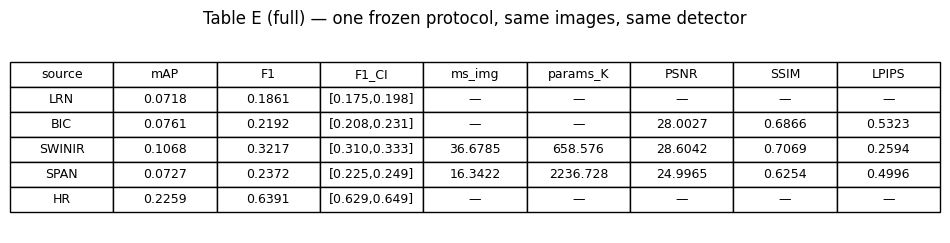

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/tableE_full.png


,source,mAP,F1,F1_CI,ms_img,params_K,PSNR,SSIM,LPIPS
0,LRN,0.0876,0.1712,"[0.147,0.193]",NaN,NaN,NaN,NaN,NaN
1,BIC,0.0916,0.2060,"[0.180,0.231]",NaN,NaN,28.0844,0.6872,0.5339
2,SWINIR,0.1271,0.3177,"[0.292,0.343]",36.6785,658.576,28.6949,0.7075,0.2603
3,SPAN,0.0782,0.2209,"[0.193,0.251]",16.3422,2236.728,25.0788,0.6263,0.5033
4,HR,0.2423,0.6380,"[0.618,0.657]",NaN,NaN,NaN,NaN,NaN
5,DIFIISR,0.0715,0.2512,"[0.228,0.276]",682.1412,NaN,25.8412,0.5837,0.3127


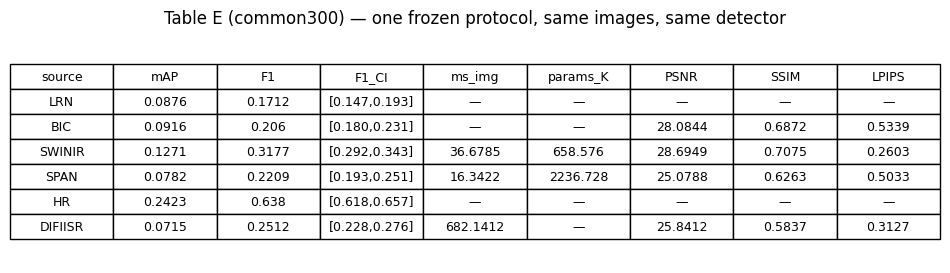

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/tableE_common300.png


In [ ]:
#@title 9.1 - Table E: full set and common subset
require('DET_FULL', 'DET_300', 'METRICS', 'TIMING', 'N_PARAMS')
def table_E(stems_tag, det, srcs):
    m = METRICS[METRICS.stem.isin(SUB300)] if stems_tag == 'common300' else METRICS
    rows = []
    for src in srcs:
        r = {'source': src}
        if src in m.source.unique():
            g = m[m.source == src]
            r.update(PSNR=g.psnr.mean(), SSIM=g.ssim.mean(), LPIPS=g.lpips.mean())
        d = det.get(src, {})
        r.update(mAP=d.get('mAP'), F1=d.get('F1'),
                 F1_CI=f"[{d['F1_lo']:.3f},{d['F1_hi']:.3f}]" if d else None,
                 ms_img=TIMING.get(src), params_K=(N_PARAMS.get(src, 0) / 1e3) or None)
        rows.append(r)
    df = pd.DataFrame(rows).round(4)
    df.to_csv(f"{P['assets']}/tableE_{stems_tag}.csv", index=False); display(df)
    fig, ax = plt.subplots(figsize=(12, 0.5 + 0.4 * len(df))); ax.axis('off')
    t = ax.table(cellText=df.fillna('—').values, colLabels=df.columns, loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.5)
    ax.set_title(f"Table E ({stems_tag}) — one frozen protocol, same images, same detector", pad=12)
    save_and_show(fig, f"tableE_{stems_tag}.png")
    return df

TE_FULL = table_E('full', DET_FULL, [s for s in ['LRN','BIC','SWINIR','SPAN','HR'] if s in DET_FULL])
TE_300  = table_E('common300', DET_300, list(SOURCES))
RESULTS['table_E_full'] = TE_FULL.to_dict('records'); RESULTS['table_E_300'] = TE_300.to_dict('records')


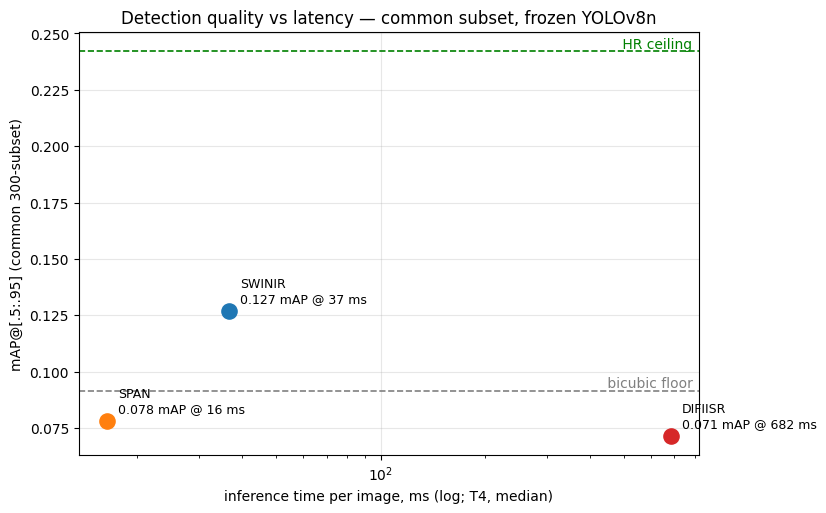

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/fig_map_vs_logtime.png


In [ ]:
#@title 9.2 - Detection quality vs inference time
require('DET_300', 'TIMING')
fig, ax = plt.subplots(figsize=(8, 5.5))
floor, ceil = DET_300['BIC']['mAP'], DET_300['HR']['mAP']
ax.axhline(ceil, color='green', ls='--', lw=1.2); ax.text(0.99, ceil, ' HR ceiling', color='green', va='bottom', ha='right', transform=ax.get_yaxis_transform())
ax.axhline(floor, color='gray', ls='--', lw=1.2); ax.text(0.99, floor, ' bicubic floor', color='gray', va='bottom', ha='right', transform=ax.get_yaxis_transform())
colors = {'SWINIR': 'tab:blue', 'SPAN': 'tab:orange', 'DIFIISR': 'tab:red'}
for src in [s for s in ['SWINIR', 'SPAN', 'DIFIISR'] if s in DET_300 and TIMING.get(s)]:
    x, y = TIMING[src], DET_300[src]['mAP']
    ax.scatter(x, y, s=120, color=colors[src], zorder=3)
    lo, hi = DET_300[src]['F1_lo'], DET_300[src]['F1_hi']   # Confidence interval reported for F1; mAP shown as point estimate
    ax.annotate(f"{src}\n{y:.3f} mAP @ {x:.0f} ms", (x, y), textcoords='offset points', xytext=(8, 6), fontsize=9)
ax.set_xscale('log'); ax.set_xlabel('inference time per image, ms (log; T4, median)'); ax.set_ylabel('mAP@[.5:.95] (common 300-subset)')
ax.set_title('Detection quality vs latency — common subset, frozen YOLOv8n')
ax.grid(alpha=0.3)
save_and_show(fig, 'fig_map_vs_logtime.png')


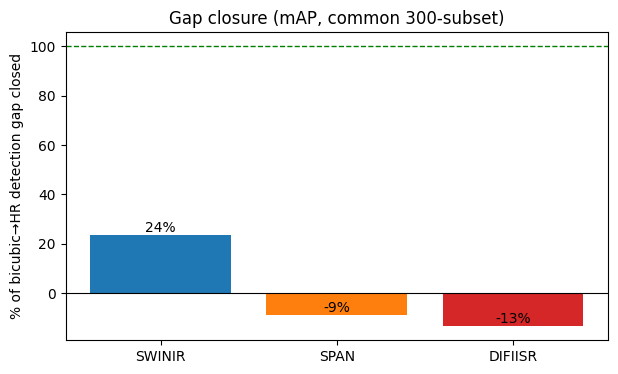

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/fig_gap_closure.png


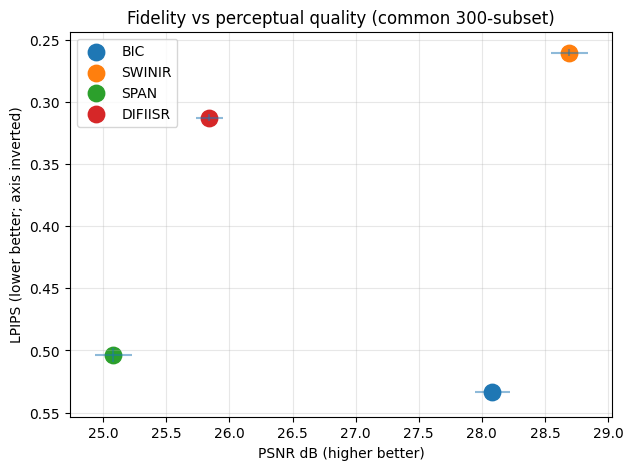

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/fig_fidelity_vs_perceptual.png


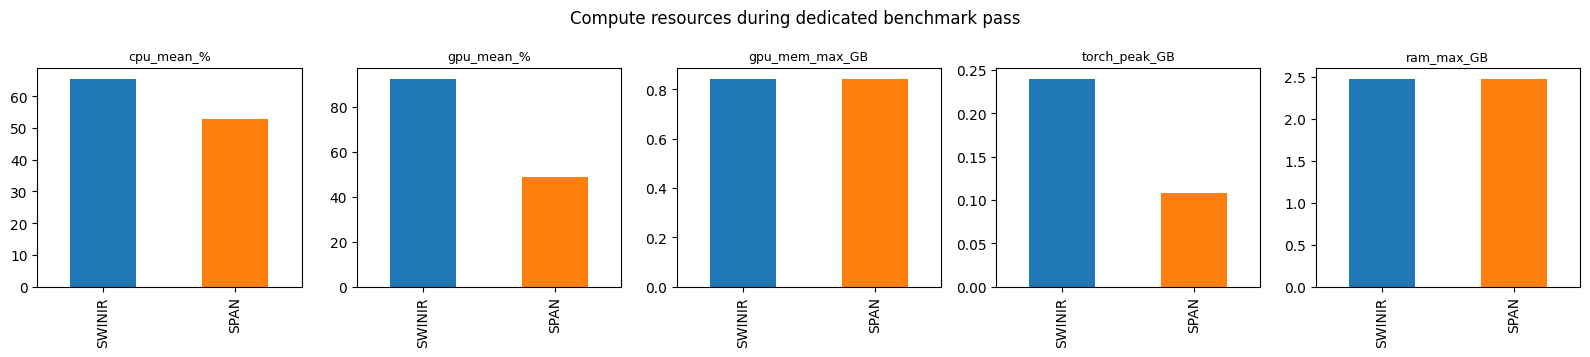

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/fig_resources.png


In [ ]:
#@title 9.3 - Gap closure, fidelity-perceptual trade-off, resource usage
# Proportion of the bicubic-to-HR mAP gap recovered, common subset
require('DET_300', 'METRICS')
fig, ax = plt.subplots(figsize=(7, 4))
gap = ceil - floor
srcs = [s for s in ['SWINIR', 'SPAN', 'DIFIISR'] if s in DET_300]
vals = [100 * (DET_300[s]['mAP'] - floor) / (gap + 1e-9) for s in srcs]
ax.bar(srcs, vals, color=[colors[s] for s in srcs])
for i, v in enumerate(vals): ax.text(i, v, f"{v:.0f}%", ha='center', va='bottom')
ax.axhline(0, color='k', lw=0.8); ax.axhline(100, color='green', ls='--', lw=1)
ax.set_ylabel('% of bicubic→HR detection gap closed'); ax.set_title('Gap closure (mAP, common 300-subset)')
save_and_show(fig, 'fig_gap_closure.png')
RESULTS['gap_closure_pct'] = dict(zip(srcs, [float(v) for v in vals]))

# Fidelity (PSNR) against perceptual similarity (LPIPS, lower is better)
fig, ax = plt.subplots(figsize=(7, 5))
msub = METRICS[METRICS.stem.isin(SUB300)]
for src in [s for s in ['BIC', 'SWINIR', 'SPAN', 'DIFIISR'] if s in msub.source.unique()]:
    g = msub[msub.source == src]
    ax.scatter(g.psnr.mean(), g.lpips.mean(), s=140, label=src)
    ax.errorbar(g.psnr.mean(), g.lpips.mean(), xerr=g.psnr.std()/np.sqrt(len(g)), yerr=g.lpips.std()/np.sqrt(len(g)), fmt='none', alpha=0.5)
ax.invert_yaxis(); ax.set_xlabel('PSNR dB (higher better)'); ax.set_ylabel('LPIPS (lower better; axis inverted)')
ax.legend(); ax.grid(alpha=0.3); ax.set_title('Fidelity vs perceptual quality (common 300-subset)')
save_and_show(fig, 'fig_fidelity_vs_perceptual.png')

# Resource usage
if RES_REPORTS:
    rd = pd.DataFrame(RES_REPORTS).set_index('tag')
    cols = [c for c in ['cpu_mean_%', 'gpu_mean_%', 'gpu_mem_max_GB', 'torch_peak_GB', 'ram_max_GB'] if c in rd]
    fig, axes = plt.subplots(1, len(cols), figsize=(3.2 * len(cols), 3.6))
    for ax, c in zip(np.atleast_1d(axes), cols):
        rd[c].plot.bar(ax=ax, color=[colors.get(t, 'tab:gray') for t in rd.index]); ax.set_title(c, fontsize=9); ax.set_xlabel('')
    fig.suptitle('Compute resources during dedicated benchmark pass'); fig.tight_layout()
    save_and_show(fig, 'fig_resources.png')


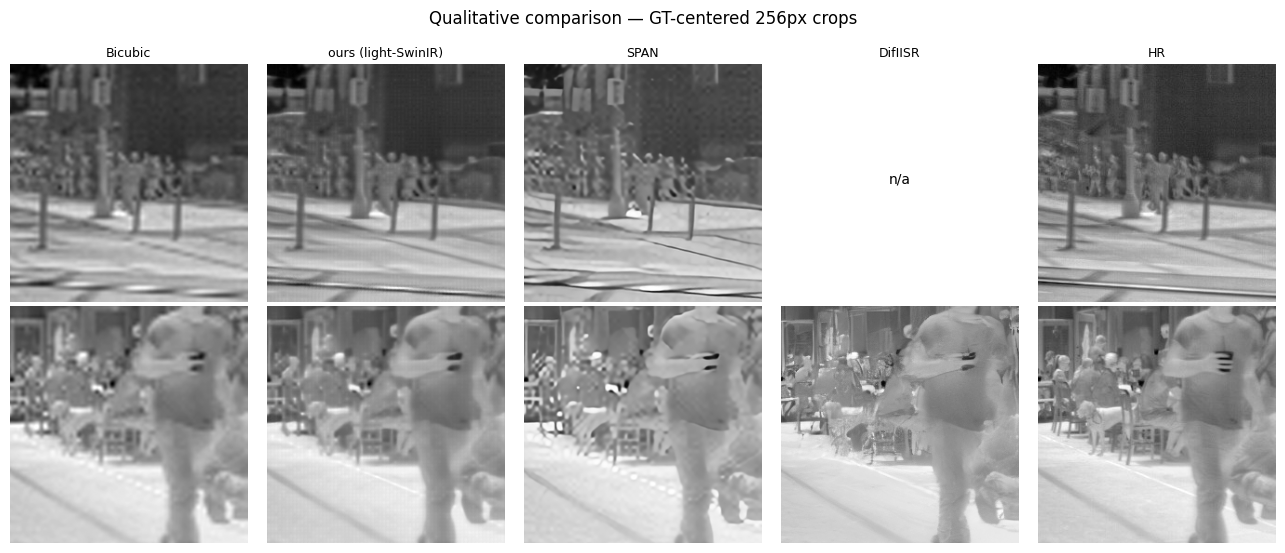

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/fig_qualitative_5way.png


In [ ]:
#@title 9.4 - Qualitative comparison crops
require('GT', 'bw_index', 'SUB300')
def n_persons(s): return sum(1 for g in GT.get(s, []) if g['cls'] == 'person')
pick1 = bw_index['SWINIR']['best_gain'][0]
pick2 = max(SUB300, key=n_persons)
picks = [pick1, pick2] if pick1 != pick2 else [pick1, bw_index['SWINIR']['best_gain'][1]]
cols = [('Bicubic', 'BIC'), ('ours (light-SwinIR)', 'SR'), ('SPAN', 'SRSPAN')] \
     + ([('DifIISR', 'SRDIF')] if not SKIP_DIFIISR else []) + [('HR', 'HR')]

def crop_around_gt(img, s, size=256):
    boxes = [g['xyxy'] for g in GT.get(s, [])]
    if boxes:
        b = max(boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
        cx, cy = int((b[0]+b[2])/2), int((b[1]+b[3])/2)
    else: cy, cx = img.shape[0]//2, img.shape[1]//2
    y0 = np.clip(cy - size//2, 0, img.shape[0]-size); x0 = np.clip(cx - size//2, 0, img.shape[1]-size)
    return img[y0:y0+size, x0:x0+size]

fig, axes = plt.subplots(len(picks), len(cols), figsize=(2.6*len(cols), 2.8*len(picks)))
axes = np.atleast_2d(axes)
for r, s in enumerate(picks):
    for c, (tag, folder) in enumerate(cols):
        pth = f"{STAGE}/{folder}/{s}.png"
        ok = os.path.exists(pth) and (folder != 'SRDIF' or s in set(SUB300))
        ax = axes[r, c]; ax.axis('off')
        if ok: ax.imshow(crop_around_gt(cv2.imread(pth, cv2.IMREAD_GRAYSCALE), s), cmap='gray')
        else: ax.text(0.5, 0.5, 'n/a', ha='center')
        if r == 0: ax.set_title(tag, fontsize=9)
fig.suptitle('Qualitative comparison — GT-centered 256px crops', fontsize=12)
fig.tight_layout(); save_and_show(fig, 'fig_qualitative_5way.png')


## Section 10 - Validation gates and coverage


In [ ]:
#@title 10.1 - Validation gates and output coverage
require('METRICS', 'DET_300', 'RESULTS')
G = RESULTS['gates']
# G3: fidelity sanity
means = METRICS.groupby('source')[['psnr', 'lpips']].mean()
g3 = all(means.loc[s, 'psnr'] >= means.loc['BIC', 'psnr'] for s in SR_SOURCES if s in means.index)
if 'DIFIISR' in means.index:
    m300 = METRICS[METRICS.stem.isin(SUB300)].groupby('source')[['lpips']].mean()
    g3 = g3 and (m300.loc['DIFIISR', 'lpips'] <= m300.loc['BIC', 'lpips'])
G['G3_fidelity'] = bool(g3)
# G4: ordering on the common subset
best_sr = max((DET_300[s]['mAP'] for s in SR_SOURCES if s in DET_300), default=0)
G['G4_ordering'] = bool(DET_300['BIC']['mAP'] < best_sr < DET_300['HR']['mAP']
                        and DET_300.get('LRN', {'mAP': 0})['mAP'] <= DET_300['BIC']['mAP'] + 1e-6)
# G5: gap closure and fidelity/task dissociation
G['G5_gap25'] = bool(max(RESULTS['gap_closure_pct'].values(), default=0) >= 25)
if 'DIFIISR' in DET_300 and 'SWINIR' in DET_300:
    m300 = METRICS[METRICS.stem.isin(SUB300)].groupby('source').psnr.mean()
    G['G5_dissociation_DifIISR'] = bool(m300['DIFIISR'] < m300['SWINIR'] and
                                        DET_300['DIFIISR']['mAP'] > DET_300['SWINIR']['mAP'])
RESULTS['timing_ms'] = TIMING
atomic_write_json(RESULTS, f"{P['assets']}/results_comparison.json")

missing = [a for a in EXPECTED_ASSETS if not os.path.exists(f"{P['assets']}/{a}")]
G['G6_coverage'] = not missing
print(json.dumps(G, indent=1))
if missing: print("Missing artifacts:", missing)
else: print(f"ALL {len(EXPECTED_ASSETS)} expected assets present in {P['assets']}")


{
 "G2_data": {
  "n_test": 1366,
  "n_sub300": 300,
  "hr_eq_lr": true
 },
 "G1_provenance": {
  "ours": "lisn_best.pth",
  "ours_ok": true,
  "span": {
   "file": "spanx4_ch48.pth",
   "scale": 4,
   "feature_channels": 48,
   "params": 2236728
  }
 },
 "G3_fidelity": false,
 "G4_ordering": true,
 "G5_gap25": false,
 "G5_dissociation_DifIISR": false,
 "G6_coverage": true
}
ALL 17 expected assets present in /content/drive/MyDrive/LISN_Project/presentation_assets


---
## Notes on scope and comparability

**LISN.** Excluded from Table E: no public weights are available, and the released code implements a
different block structure from the one described in the paper. It is reported in Table L only.

**Off-the-shelf evaluation.** External models are evaluated without fine-tuning. Matching training budgets
across LISN, SPAN and DifIISR is not feasible, and a partial fine-tune would be arbitrary. The contrast
between domain-matched training and off-the-shelf generality is therefore the variable under study rather
than a confound. All low-resolution inputs are clean bicubic x4, which matches SPAN's training degradation,
so degradation mismatch does not apply.

**Subset size.** DifIISR is evaluated on a seeded subset drawn once, with the manifest written before
inference. All head-to-head figures are recomputed on that subset for every source.

**Detector.** The frozen COCO-pretrained detector is a deliberate control: it has not seen any image in this
dataset, so no source is advantaged by detector familiarity. Absolute values are consequently low. Section 11
repeats the comparison with a detector trained on the FLIR training split.

**Fidelity and task metrics may disagree.** A model can score well on LPIPS and poorly on mAP, or the
reverse. Both are reported, and gate G5 records the direction explicitly.


---
# Section 11 - Sensitivity analysis: domain-matched detector

The declared protocol uses a frozen COCO-pretrained YOLOv8n (deviation 4). This section repeats the
comparison with a detector trained on the FLIR training split, to establish whether the ranking of
super-resolution models depends on the detector.

The detector is trained in the separate notebook `YOLO_thermal_FLIR_training.ipynb`, which writes
`checkpoints/yolov8n_flir_thermal.pt`. Cell 11.1 requires 8.3 to have run. Section 11 supplements
Table E and does not replace it; both detectors are reported.


Frozen-COCO predictions loaded from cache
Thermal-detector predictions loaded from cache


,source,mAP_coco,F1_coco,mAP_thermal,F1_thermal,F1_th_CI
0,LRN,0.0876,0.1712,0.2033,0.6110,"[0.590,0.632]"
1,BIC,0.0916,0.2060,0.1923,0.6106,"[0.590,0.631]"
2,SWINIR,0.1271,0.3177,0.2288,0.6517,"[0.632,0.669]"
3,SPAN,0.0782,0.2209,0.1553,0.5301,"[0.508,0.552]"
4,HR,0.2423,0.6380,0.3052,0.7504,"[0.734,0.766]"
5,DIFIISR,0.0715,0.2512,0.1324,0.4662,"[0.442,0.492]"


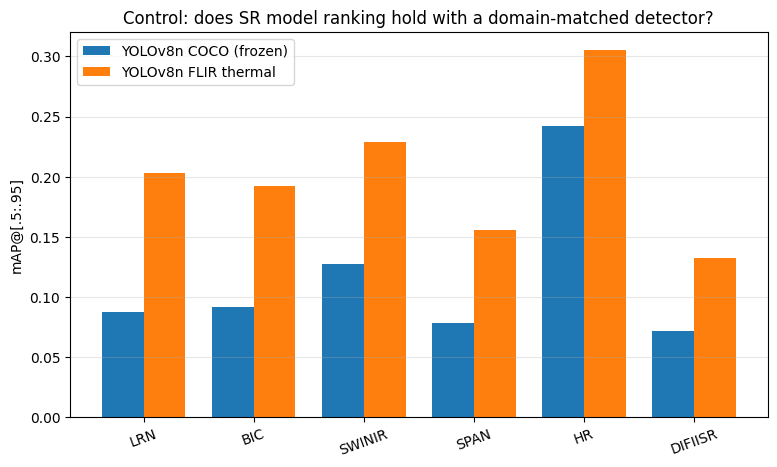

  saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/fig_two_detectors.png
Ranking (frozen COCO): {'BIC': 2.0, 'SWINIR': 1.0, 'SPAN': 3.0, 'DIFIISR': 4.0}
Ranking (thermal)    : {'BIC': 2.0, 'SWINIR': 1.0, 'SPAN': 3.0, 'DIFIISR': 4.0}
Ranking preserved

HR mAP_thermal = 0.3052 - within the expected range.


In [20]:
#@title 11.1 - Detector comparison on the common subset
# Prerequisites: 8.3 must have run; thermal weights come from YOLO_thermal_FLIR_training.ipynb.
require('map_eval', 'boot_f1', 'f1_per_image', 'SUB300', 'PRED')
from ultralytics import YOLO

# Re-declared defensively; normally set in 8.2
COCO_ID2NAME = {0: 'person', 1: 'bicycle', 2: 'car', 16: 'dog'}
SOURCES = {'LRN': ('LR', 4.0), 'BIC': ('BIC', 1.0), 'SWINIR': ('SR', 1.0),
           'SPAN': ('SRSPAN', 1.0), 'HR': ('HR', 1.0)}
if not SKIP_DIFIISR:
    SOURCES['DIFIISR'] = ('SRDIF', 1.0)
#-------------------
# Load cached frozen-COCO predictions
pred_cache = f"{P['cache']}/yolo_preds_{len(TEST_STEMS)}.json"
if os.path.exists(pred_cache):
    PRED = json.load(open(pred_cache)); print("Frozen-COCO predictions loaded from cache")
else:
    raise RuntimeError("COCO predictions not cached — run 8.2 first")
#-------------------
YOLO_THERMAL = f"{P['ckpt']}/yolov8n_flir_thermal.pt"
if not os.path.exists(YOLO_THERMAL):
    _alt = f"{DRIVE_ROOT}/datasets/checkpoints/yolov8n_flir_thermal.pt"
    if os.path.exists(_alt):
        shutil.copy2(_alt, YOLO_THERMAL)
        print(f"Weights copied from {_alt}")
assert os.path.exists(YOLO_THERMAL), (
    f"Thermal detector weights not found at {YOLO_THERMAL}. "
    f"Run YOLO_thermal_FLIR_training.ipynb first.")

yolo_th = YOLO(YOLO_THERMAL)
TH_NAMES = ['person', 'bicycle', 'car', 'dog']

# Predictions from the thermal detector
th_cache = f"{P['cache']}/yolo_thermal_preds_{len(TEST_STEMS)}.json"
if os.path.exists(th_cache):
    PRED_TH = json.load(open(th_cache)); print("Thermal-detector predictions loaded from cache")
else:
    PRED_TH = {}
    for src, (folder, bscale) in SOURCES.items():
        stems = SUB300 if src == 'DIFIISR' else TEST_STEMS
        PRED_TH[src] = {}
        for i, s in enumerate(stems):
            r = yolo_th.predict(f"{STAGE}/{folder}/{s}.png", conf=CONFIG['conf_pred'], verbose=False)[0]
            PRED_TH[src][s] = {'xyxy': (r.boxes.xyxy.cpu().numpy() * bscale).tolist(),
                               'conf': r.boxes.conf.cpu().numpy().tolist(),
                               'cls':  [TH_NAMES[int(c)] for c in r.boxes.cls.cpu().numpy()]}
            if (i+1) % 200 == 0: print(f"  {src} {i+1}/{len(stems)}")
        print(f"{src}: complete")
    atomic_write_json(PRED_TH, th_cache)

# Evaluate both detectors on the common subset
_PRED_ORIG = PRED.copy()
rows = []
for src in SOURCES:
    r = {'source': src}
    # Frozen COCO detector
    PRED = _PRED_ORIG
    r['mAP_coco'] = map_eval(SUB300, src)[0]
    r['F1_coco']  = boot_f1(f1_per_image(SUB300, src))[0]
    # Thermal detector
    PRED = PRED_TH
    r['mAP_thermal'] = map_eval(SUB300, src)[0]
    f1m, lo, hi = boot_f1(f1_per_image(SUB300, src))
    r['F1_thermal'] = f1m; r['F1_th_CI'] = f"[{lo:.3f},{hi:.3f}]"
    rows.append(r)
PRED = _PRED_ORIG

CMP = pd.DataFrame(rows).round(4)
CMP.to_csv(f"{P['assets']}/tableE_two_detectors.csv", index=False)
display(CMP)

# Ranking comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(CMP)); w = 0.38
ax.bar(x - w/2, CMP.mAP_coco,    w, label='YOLOv8n COCO (frozen)', color='tab:blue')
ax.bar(x + w/2, CMP.mAP_thermal, w, label='YOLOv8n FLIR thermal',  color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(CMP.source, rotation=20)
ax.set_ylabel('mAP@[.5:.95]'); ax.legend(); ax.grid(alpha=.3, axis='y')
ax.set_title('Control: does SR model ranking hold with a domain-matched detector?')
save_and_show(fig, 'fig_two_detectors.png')

# Ranking consistency
sr = [s for s in ['BIC','SWINIR','SPAN','DIFIISR'] if s in CMP.source.values]
o1 = CMP.set_index('source').loc[sr,'mAP_coco'].rank(ascending=False).to_dict()
o2 = CMP.set_index('source').loc[sr,'mAP_thermal'].rank(ascending=False).to_dict()
print("Ranking (frozen COCO):", o1)
print("Ranking (thermal)    :", o2)
print("Ranking preserved" if o1 == o2 else "Ranking differs between detectors")

# Guard: an implausibly low HR score indicates a defective detector
_hr = CMP.set_index('source').loc['HR', 'mAP_thermal']
if _hr < 0.15:
    print(f"\nWARNING: HR mAP_thermal = {_hr:.4f} is implausibly low. Verify the detector was trained on "
          f"train/thermal_8_bit rather than train/Annotated_thermal_8_bit. These results are not reportable.")
else:
    print(f"\nHR mAP_thermal = {_hr:.4f} - within the expected range.")


In [21]:
#@title 11.2 - Thermal detector on the FULL set (predictions already exist from 11.1)
require('map_eval', 'boot_f1', 'f1_per_image', 'TEST_STEMS', 'PRED')

# PRED_TH already holds full-set predictions for every source except DIFIISR
if 'PRED_TH' not in globals():
    _th_cache = f"{P['cache']}/yolo_thermal_preds_{len(TEST_STEMS)}.json"
    assert os.path.exists(_th_cache), "run 11.1 first"
    PRED_TH = json.load(open(_th_cache))
    print("PRED_TH loaded from cache")

for k, v in PRED_TH.items():
    print(f"  {k:8s} {len(v):5d} images")

FULL_SRC = [s for s in ['LRN', 'BIC', 'SWINIR', 'SPAN', 'HR']
            if len(PRED_TH.get(s, {})) == len(TEST_STEMS)]
print(f"\nsources with full coverage: {FULL_SRC}")

_PRED_ORIG = PRED           # map_eval / f1_per_image read the global PRED
rows_th_full = []
try:
    PRED = PRED_TH
    for src in FULL_SRC:
        mAP, per = map_eval(TEST_STEMS, src)
        f1m, lo, hi = boot_f1(f1_per_image(TEST_STEMS, src))
        rows_th_full.append({'source': src, 'mAP_thermal_full': round(mAP, 4),
                             'F1_thermal_full': round(f1m, 4),
                             'F1_CI': f"[{lo:.3f},{hi:.3f}]"})
        print(f"{src:8s} mAP={mAP:.4f}  F1={f1m:.4f}  CI=[{lo:.3f},{hi:.3f}]")
finally:
    PRED = _PRED_ORIG        # always restore, even if a cell above raised

TH_FULL = pd.DataFrame(rows_th_full)
display(TH_FULL)

# ---------- gap closure, full set, thermal detector ----------
g = TH_FULL.set_index('source')['mAP_thermal_full']
floor, ceil = g['BIC'], g['HR']
print(f"\nfloor (bicubic) = {floor:.4f}    ceiling (HR) = {ceil:.4f}    span = {ceil - floor:.4f}")
print("\ngap closure - FULL set (1,366), thermal detector:")
for src in [s for s in ['SWINIR', 'SPAN', 'LRN'] if s in g.index]:
    gc = (g[src] - floor) / (ceil - floor) * 100
    print(f"  {src:8s} mAP={g[src]:.4f}   gap closure = {gc:+.1f}%")

# sanity guard, same threshold as 11.1
if ceil < 0.15:
    print(f"\nWARNING: HR mAP = {ceil:.4f} is implausibly low - check the detector weights.")

TH_FULL.to_csv(f"{P['assets']}/tableE_thermal_full.csv", index=False)
print(f"\nsaved -> {P['assets']}/tableE_thermal_full.csv")

  LRN       1366 images
  BIC       1366 images
  SWINIR    1366 images
  SPAN      1366 images
  HR        1366 images
  DIFIISR    300 images

sources with full coverage: ['LRN', 'BIC', 'SWINIR', 'SPAN', 'HR']
LRN      mAP=0.1890  F1=0.6138  CI=[0.603,0.623]
BIC      mAP=0.1829  F1=0.6144  CI=[0.605,0.623]
SWINIR   mAP=0.2149  F1=0.6537  CI=[0.644,0.663]
SPAN     mAP=0.1531  F1=0.5266  CI=[0.516,0.536]
HR       mAP=0.3044  F1=0.7607  CI=[0.754,0.768]


,source,mAP_thermal_full,F1_thermal_full,F1_CI
0,LRN,0.1890,0.6138,"[0.603,0.623]"
1,BIC,0.1829,0.6144,"[0.605,0.623]"
2,SWINIR,0.2149,0.6537,"[0.644,0.663]"
3,SPAN,0.1531,0.5266,"[0.516,0.536]"
4,HR,0.3044,0.7607,"[0.754,0.768]"



floor (bicubic) = 0.1829    ceiling (HR) = 0.3044    span = 0.1215

gap closure - FULL set (1,366), thermal detector:
  SWINIR   mAP=0.2149   gap closure = +26.3%
  SPAN     mAP=0.1531   gap closure = -24.5%
  LRN      mAP=0.1890   gap closure = +5.0%

saved -> /content/drive/MyDrive/LISN_Project/presentation_assets/tableE_thermal_full.csv


### Interpretation

A preserved ranking indicates that the result is not an artifact of detector-domain mismatch. A changed
ranking indicates that detector choice is an experimental parameter rather than neutral background; in that
case both tables are reported and the dependency is stated explicitly.

Table E, computed with the frozen COCO detector, remains the primary result in either case.


---
## Section 12 - Presentation figures

High-resolution (300 dpi) versions of the headline figures, with consistent naming
(the local model is labelled "light-SwinIR (ours)" everywhere) and a shared palette.
Files are written with a PRES_ prefix. Requires 8.3; cell 12.1 additionally uses the
detector-comparison table from 11.1 when it exists.


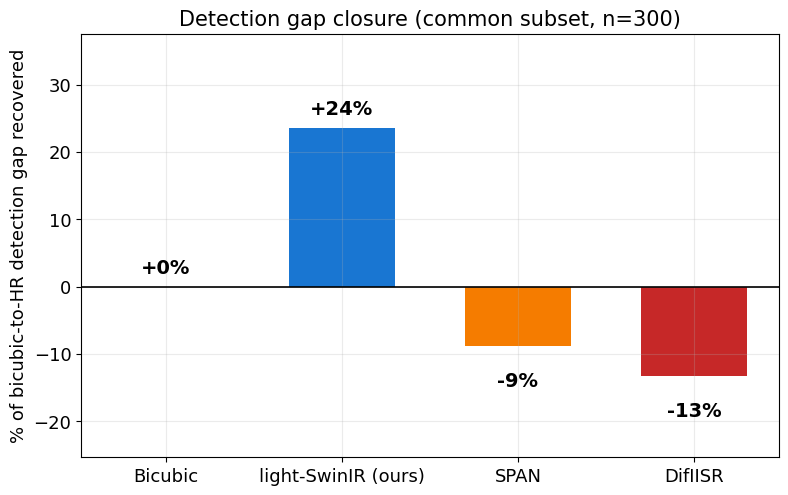

saved PRES_01_gap_closure.png


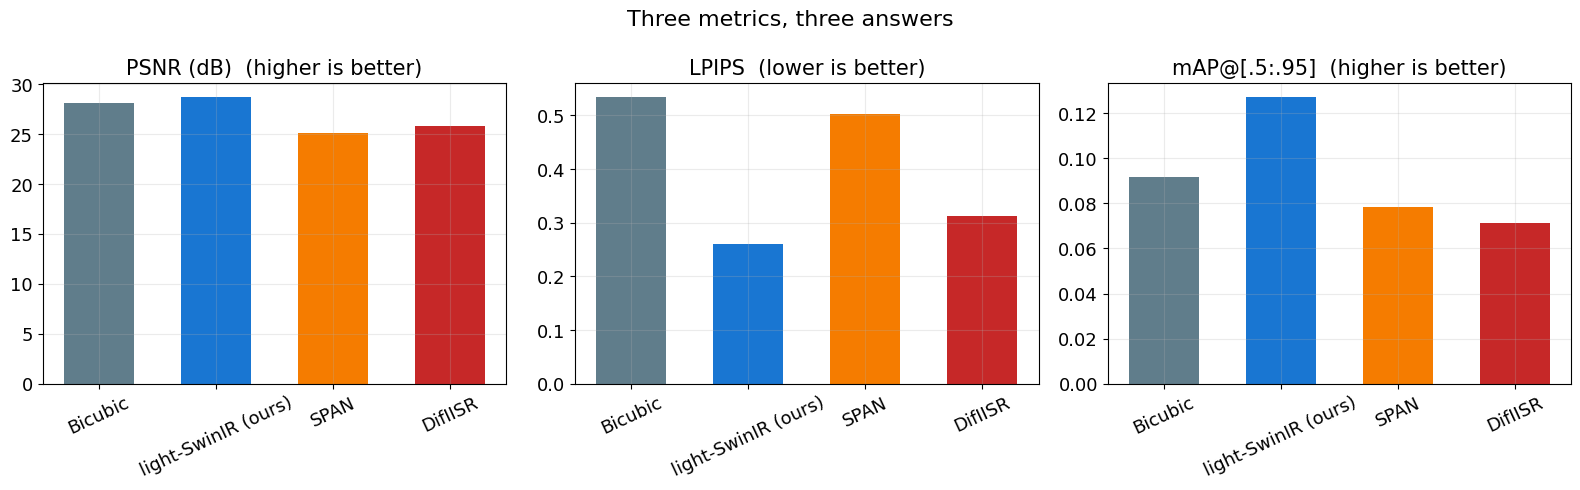

saved PRES_02_three_metrics.png


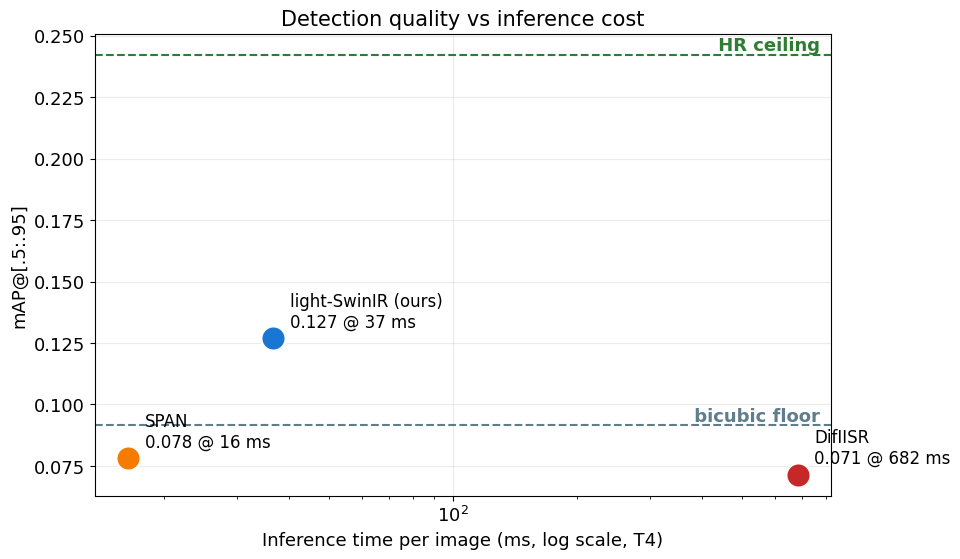

saved PRES_03_quality_vs_latency.png


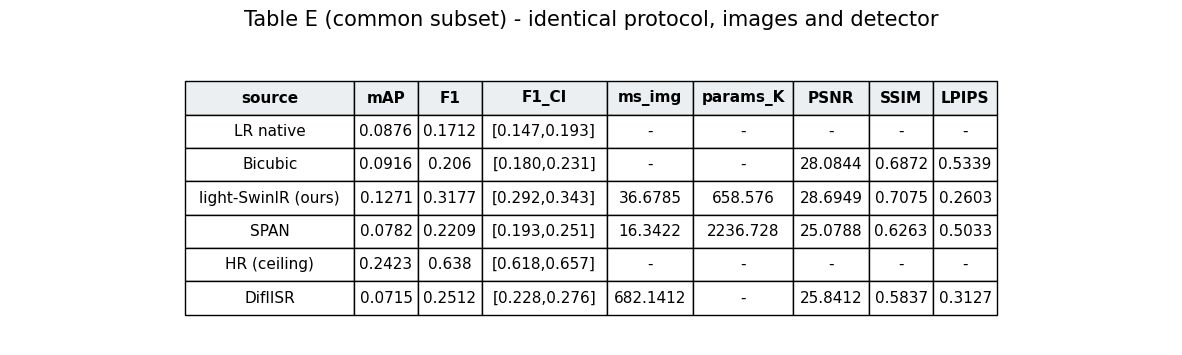

saved PRES_04_tableE.png


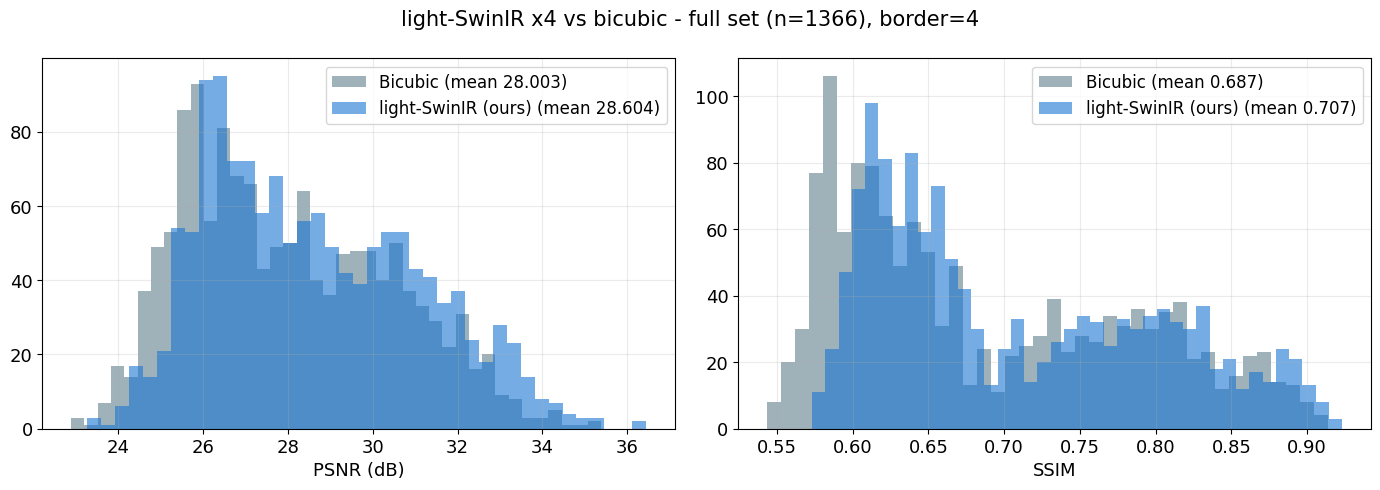

saved PRES_05_metrics_hist.png


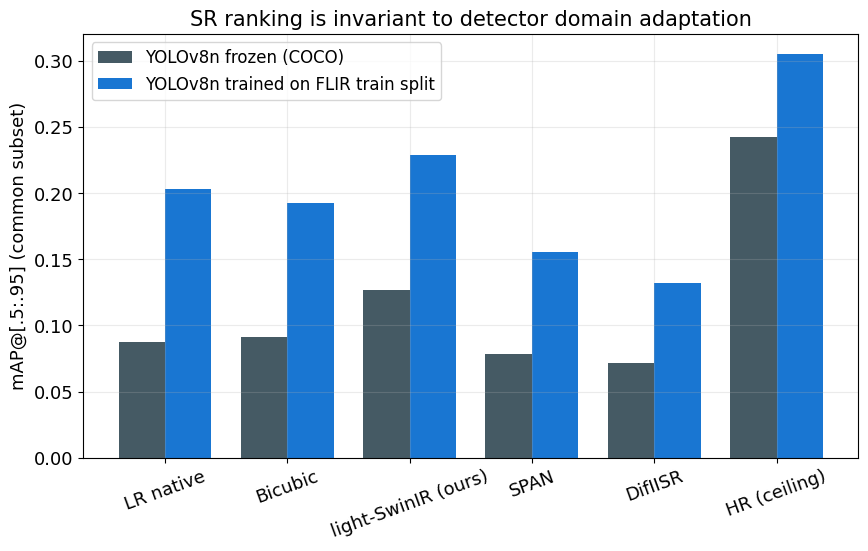

saved PRES_06_two_detectors.png
Presentation figures complete.


In [ ]:
#@title 12.1 - Presentation figures (300 dpi)
require('DET_300', 'METRICS', 'SUB300', 'TIMING', 'N_PARAMS')
import matplotlib as mpl
mpl.rcParams.update({'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
                     'legend.fontsize': 12, 'figure.facecolor': 'white',
                     'axes.grid': True, 'grid.alpha': 0.25})
LABEL = {'LRN': 'LR native', 'BIC': 'Bicubic', 'SWINIR': 'light-SwinIR (ours)',
         'SPAN': 'SPAN', 'DIFIISR': 'DifIISR', 'HR': 'HR (ceiling)'}
COLOR = {'LRN': '#9e9e9e', 'BIC': '#607d8b', 'SWINIR': '#1976d2',
         'SPAN': '#f57c00', 'DIFIISR': '#c62828', 'HR': '#2e7d32'}
def save_hi(fig, name):
    fig.savefig(f"{P['assets']}/{name}", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(fig); print(f"saved {name}")

D = DET_300
srcs = [s for s in ['BIC', 'SWINIR', 'SPAN', 'DIFIISR'] if s in D]
floor, ceil = D['BIC']['mAP'], D['HR']['mAP']

# A. Gap closure
fig, ax = plt.subplots(figsize=(9, 5.5))
vals = [100 * (D[s]['mAP'] - floor) / (ceil - floor) for s in srcs]
bars = ax.bar([LABEL[s] for s in srcs], vals, color=[COLOR[s] for s in srcs], width=.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + (2 if v >= 0 else -6), f"{v:+.0f}%",
            ha='center', fontweight='bold', fontsize=14)
ax.axhline(0, color='k', lw=1.2)
ax.set_ylabel('% of bicubic-to-HR detection gap recovered')
ax.set_title('Detection gap closure (common subset, n=300)')
ax.set_ylim(min(vals) - 12, max(vals) + 14)
save_hi(fig, 'PRES_01_gap_closure.png')

# B. Three metrics side by side
M = METRICS[METRICS.stem.isin(SUB300)].groupby('source')[['psnr', 'lpips']].mean()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, lab, better) in zip(axes, [('psnr', 'PSNR (dB)', 'higher is better'),
                                          ('lpips', 'LPIPS', 'lower is better'),
                                          (None, 'mAP@[.5:.95]', 'higher is better')]):
    d = [M.loc[s, col] if col else D[s]['mAP'] for s in srcs]
    ax.bar([LABEL[s] for s in srcs], d, color=[COLOR[s] for s in srcs], width=.6)
    ax.set_title(f"{lab}  ({better})"); ax.tick_params(axis='x', rotation=25)
fig.suptitle('Three metrics, three answers', fontsize=16)
fig.tight_layout(); save_hi(fig, 'PRES_02_three_metrics.png')

# C. Quality vs latency
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.axhline(ceil, color=COLOR['HR'], ls='--', lw=1.5)
ax.text(0.985, ceil, ' HR ceiling', color=COLOR['HR'], va='bottom', ha='right',
        transform=ax.get_yaxis_transform(), fontweight='bold')
ax.axhline(floor, color=COLOR['BIC'], ls='--', lw=1.5)
ax.text(0.985, floor, ' bicubic floor', color=COLOR['BIC'], va='bottom', ha='right',
        transform=ax.get_yaxis_transform(), fontweight='bold')
for s in [x for x in srcs if x != 'BIC' and TIMING.get(x)]:
    ax.scatter(TIMING[s], D[s]['mAP'], s=320, color=COLOR[s], zorder=3,
               edgecolor='white', lw=2)
    ax.annotate(f"{LABEL[s]}\n{D[s]['mAP']:.3f} @ {TIMING[s]:.0f} ms",
                (TIMING[s], D[s]['mAP']), textcoords='offset points', xytext=(12, 8), fontsize=12)
ax.set_xscale('log')
ax.set_xlabel('Inference time per image (ms, log scale, T4)')
ax.set_ylabel('mAP@[.5:.95]')
ax.set_title('Detection quality vs inference cost')
save_hi(fig, 'PRES_03_quality_vs_latency.png')

# D. Table E, readable
te = pd.read_csv(f"{P['assets']}/tableE_common300.csv")
te['source'] = te['source'].map(lambda s: LABEL.get(s, s))
fig, ax = plt.subplots(figsize=(15, 0.7 + 0.52 * len(te))); ax.axis('off')
t = ax.table(cellText=te.fillna('-').values, colLabels=te.columns, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1, 2.0)
t.auto_set_column_width(col=list(range(len(te.columns))))
for j in range(len(te.columns)):
    t[(0, j)].set_facecolor('#eceff1'); t[(0, j)].set_text_props(fontweight='bold')
ax.set_title('Table E (common subset) - identical protocol, images and detector', pad=18)
save_hi(fig, 'PRES_04_tableE.png')

# E. Fidelity histogram, bicubic vs local model, correct naming
full = METRICS[METRICS.source.isin(['BIC', 'SWINIR'])]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, lab in [(axes[0], 'psnr', 'PSNR (dB)'), (axes[1], 'ssim', 'SSIM')]:
    for s, cl in [('BIC', COLOR['BIC']), ('SWINIR', COLOR['SWINIR'])]:
        d = full[full.source == s][col]
        ax.hist(d, bins=40, alpha=.6, color=cl, label=f"{LABEL[s]} (mean {d.mean():.3f})")
    ax.set_xlabel(lab); ax.legend()
fig.suptitle(f'light-SwinIR x4 vs bicubic - full set (n={full.stem.nunique()}), border=4', fontsize=15)
fig.tight_layout(); save_hi(fig, 'PRES_05_metrics_hist.png')

# F. Detector comparison, when 11.1 has produced CMP
if 'CMP' in globals():
    fig, ax = plt.subplots(figsize=(10, 5.5))
    order = [s for s in ['LRN', 'BIC', 'SWINIR', 'SPAN', 'DIFIISR', 'HR'] if s in CMP.source.values]
    cc = CMP.set_index('source').loc[order]
    x = np.arange(len(order)); w = 0.38
    ax.bar(x - w/2, cc.mAP_coco, w, label='YOLOv8n frozen (COCO)', color='#455a64')
    ax.bar(x + w/2, cc.mAP_thermal, w, label='YOLOv8n trained on FLIR train split', color='#1976d2')
    ax.set_xticks(x); ax.set_xticklabels([LABEL[s] for s in order], rotation=20)
    ax.set_ylabel('mAP@[.5:.95] (common subset)')
    ax.set_title('SR ranking is invariant to detector domain adaptation')
    ax.legend()
    save_hi(fig, 'PRES_06_two_detectors.png')
else:
    print("CMP not in memory; run 11.1 first to produce PRES_06_two_detectors.png")
print("Presentation figures complete.")


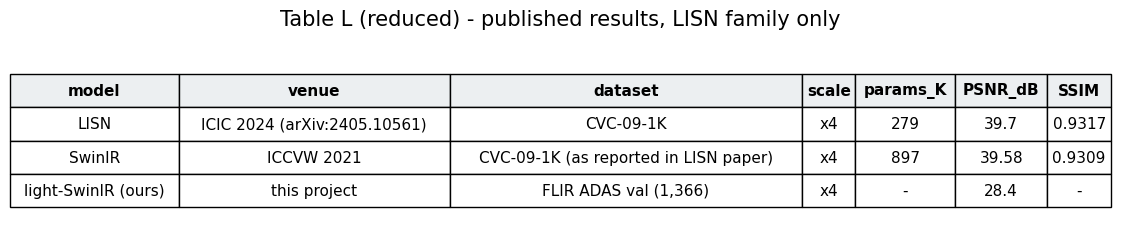

saved PRES_07_tableL_reduced.png
checkpoints carry no PSNR field - using fig02_ckpt_psnr_curve.png
saved PRES_09_slide1_bicubic_hr.png


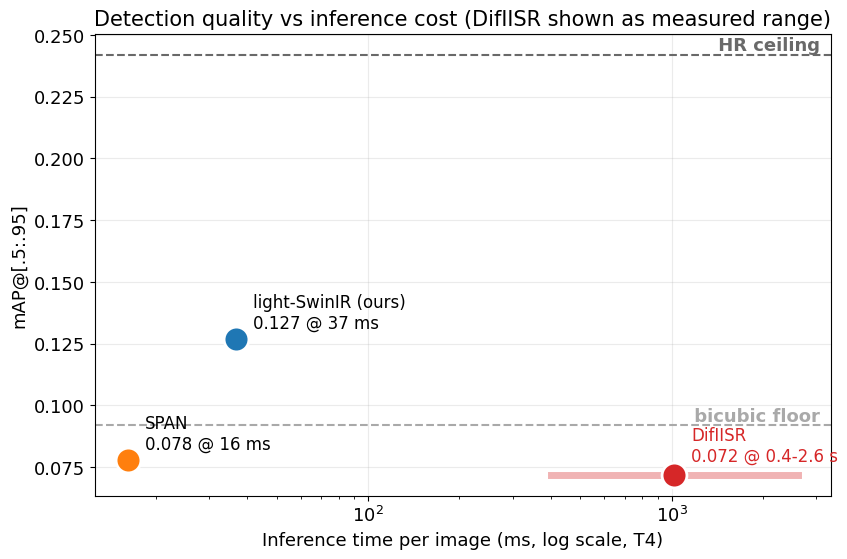

saved PRES_03b_quality_vs_latency.png
slide 3: ['PRES_09_slide1_bicubic_hr.png']
slide 9: ['fig_detection_visual_FLIR_08866.png']
slide 13: ['PRES_07_tableL_reduced.png']
slide 15: ['fig02_ckpt_psnr_curve.png', 'PRES_05_metrics_hist.png']
slide 17: ['PRES_05_metrics_hist.png']
slide 19: ['PRES_02_three_metrics.png']
slide 21: ['tableE_full.png']
slide 23: ['tableE_common300.png']
slide 25: ['PRES_01_gap_closure.png']
slide 27: ['fig_fidelity_vs_perceptual.png']
slide 29: ['PRES_02_three_metrics.png', 'fig_fidelity_vs_perceptual.png']
slide 31: ['PRES_06_two_detectors.png']
slide 33: ['PRES_03b_quality_vs_latency.png', 'fig_resources.png']
slide 35: ['PRES_01_gap_closure.png', 'PRES_06_two_detectors.png']

Deck written: /content/drive/MyDrive/LISN_Project/IR_SR_deck_v3.pptx
Slides 7 (paper figure) and 11 (GitHub-issue screenshot + provenance table) remain manual.
After rerunning 6.4 with the warm-up + 12.1, swap PRES_03b back to the real PRES_03.


In [ ]:
#@title 12.2 - Deck assembly: build missing artifacts and swap all images into the PPTX
# Requires 12.1 to have run in this session (uses P, DRIVE_ROOT, save_hi-style output dir).
# Produces: PRES_07_tableL_reduced, PRES_08_convergence (or fig02 fallback),
#           PRES_09_slide1_bicubic_hr (crop), PRES_03b (DifIISR as a range),
#           and IR_SR_deck_v3.pptx with every artifact slide populated.
require('P')
import glob, re, os, math
import pandas as pd, matplotlib.pyplot as plt
from PIL import Image

try:
    from pptx import Presentation
    from pptx.util import Inches
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'python-pptx'], check=True)
    from pptx import Presentation
    from pptx.util import Inches

A = P['assets']
DECK_IN  = f"{DRIVE_ROOT}/IR_SR_deck.pptx"
DECK_OUT = f"{DRIVE_ROOT}/IR_SR_deck_v3.pptx"
STEM = 'FLIR_08866'          # <-- pick the pedestrian-heavy stem: FLIR_08866 or FLIR_08863
assert os.path.exists(DECK_IN), f"deck not found at {DECK_IN} - fix DECK_IN"

def _save(fig, name, dpi=300):
    fig.savefig(f"{A}/{name}", dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(fig)
    print('saved', name)

# ---------- G. Reduced Table L (slide 6): LISN family only, no competitor reveal ----------
tl = pd.read_csv(f"{A}/tableL_literature.csv")
tl = tl[tl.model.str.contains('LISN|SwinIR', case=False, regex=True)]
cols = [c for c in ['model', 'venue', 'dataset', 'scale', 'params_K', 'PSNR_dB', 'SSIM'] if c in tl.columns]
fig, ax = plt.subplots(figsize=(13, 0.7 + 0.55 * len(tl))); ax.axis('off')
t = ax.table(cellText=tl[cols].fillna('-').values, colLabels=cols, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1, 2.0)
t.auto_set_column_width(col=list(range(len(cols))))
for j in range(len(cols)):
    t[(0, j)].set_facecolor('#eceff1'); t[(0, j)].set_text_props(fontweight='bold')
ax.set_title('Table L (reduced) - published results, LISN family only', pad=18)
_save(fig, 'PRES_07_tableL_reduced.png')

# ---------- H. Convergence curve (slide 7), fallback to fig02 ----------
CONV_IMG = f"{A}/fig02_ckpt_psnr_curve.png"      # default: reuse the original
rows = []
for f in sorted(glob.glob(f"{P['ckpt']}/lisn_epoch_*.pth")):
    try:
        import torch
        ck = torch.load(f, map_location='cpu', weights_only=True)
        ep = int(re.search(r'(\d+)', os.path.basename(f)).group(1))
        v = ck.get('psnr') or ck.get('best_psnr')
        if v: rows.append((ep, float(v)))
    except Exception:
        pass
if len(rows) >= 3:
    rows.sort(); ep, ps = zip(*rows)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(ep, ps, marker='o', lw=2)
    ax.axhline(28.0027, ls='--', lw=1.5, color='gray')
    ax.text(0.98, 28.0027, ' bicubic floor', va='bottom', ha='right',
            transform=ax.get_yaxis_transform(), fontweight='bold', color='gray')
    ax.set_xlabel('Training epoch'); ax.set_ylabel('Validation PSNR (dB)')
    ax.set_title('light-SwinIR converges by epoch 20; 300 epochs used, 6,000 in the paper')
    _save(fig, 'PRES_08_convergence.png')
    CONV_IMG = f"{A}/PRES_08_convergence.png"
else:
    print('checkpoints carry no PSNR field - using fig02_ckpt_psnr_curve.png')
assert os.path.exists(CONV_IMG), 'no convergence artifact available for slide 7'

# ---------- I. Slide-1 crop: bicubic + HR panels only (no result spoiler) ----------
# 8.1b grid is 2x3: [LR, BIC, ours / SPAN, DifIISR, HR]. BIC = row0-col1, HR = row1-col2.
src_img = Image.open(f"{A}/fig_detection_visual_{STEM}.png").convert('RGB')
W, H = src_img.size
top = int(0.055 * H)                       # skip the suptitle strip
cw, rh = W // 3, (H - top) // 2
bic = src_img.crop((cw, top, 2 * cw, top + rh))
hr  = src_img.crop((2 * cw, top + rh, W, top + 2 * rh))
combo = Image.new('RGB', (bic.width + hr.width + 40, max(bic.height, hr.height)), 'white')
combo.paste(bic, (0, 0)); combo.paste(hr, (bic.width + 40, 0))
combo.save(f"{A}/PRES_09_slide1_bicubic_hr.png")
print('saved PRES_09_slide1_bicubic_hr.png')

# ---------- J. PRES_03b: quality vs latency WITH DifIISR shown as a measured range ----------
# Until 6.4 reruns with the warm-up, DifIISR's defensible figure is the 0.4-2.6 s range.
pts = {'light-SwinIR (ours)': (36.7, 0.127), 'SPAN': (16.2, 0.078)}
floor, ceil, dif_map = 0.092, 0.242, 0.072
dif_lo, dif_hi = 400.0, 2600.0
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.axhline(ceil, ls='--', lw=1.5, color='dimgray')
ax.text(0.985, ceil, ' HR ceiling', va='bottom', ha='right',
        transform=ax.get_yaxis_transform(), fontweight='bold', color='dimgray')
ax.axhline(floor, ls='--', lw=1.5, color='darkgray')
ax.text(0.985, floor, ' bicubic floor', va='bottom', ha='right',
        transform=ax.get_yaxis_transform(), fontweight='bold', color='darkgray')
for lab, (ms, m) in pts.items():
    ax.scatter(ms, m, s=320, zorder=3, edgecolor='white', lw=2)
    ax.annotate(f"{lab}\n{m:.3f} @ {ms:.0f} ms", (ms, m),
                textcoords='offset points', xytext=(12, 8), fontsize=12)
gm = math.sqrt(dif_lo * dif_hi)
ax.plot([dif_lo, dif_hi], [dif_map, dif_map], lw=5, alpha=0.35, color='tab:red')
ax.scatter(gm, dif_map, s=320, zorder=3, color='tab:red', edgecolor='white', lw=2)
ax.annotate(f"DifIISR\n{dif_map:.3f} @ 0.4-2.6 s", (gm, dif_map),
            textcoords='offset points', xytext=(12, 10), fontsize=12, color='tab:red')
ax.set_xscale('log')
ax.set_xlabel('Inference time per image (ms, log scale, T4)')
ax.set_ylabel('mAP@[.5:.95]')
ax.set_title('Detection quality vs inference cost (DifIISR shown as measured range)')
_save(fig, 'PRES_03b_quality_vs_latency.png')

# ---------- K. Swap everything into the deck ----------
# pptx slide index (1-based) -> list of image files. Slides 7 & 11 stay manual.
PLAN = {
    3:  ['PRES_09_slide1_bicubic_hr.png'],
    9:  [f'fig_detection_visual_{STEM}.png'],
    13: ['PRES_07_tableL_reduced.png'],
    15: [os.path.basename(CONV_IMG), 'PRES_05_metrics_hist.png'],
    17: ['PRES_05_metrics_hist.png'],
    19: ['PRES_02_three_metrics.png'],
    21: ['tableE_full.png'],
    23: ['tableE_common300.png'],
    25: ['PRES_01_gap_closure.png'],
    27: ['fig_fidelity_vs_perceptual.png'],
    29: ['PRES_02_three_metrics.png', 'fig_fidelity_vs_perceptual.png'],
    31: ['PRES_06_two_detectors.png'],
    33: ['PRES_03b_quality_vs_latency.png', 'fig_resources.png'],
    35: ['PRES_01_gap_closure.png', 'PRES_06_two_detectors.png'],
}
missing = [f for fs in PLAN.values() for f in fs if not os.path.exists(f"{A}/{f}")]
assert not missing, f"missing on Drive: {missing}"

prs = Presentation(DECK_IN)
slides = list(prs.slides)
def _fill(slide, files, top_in=1.9, bottom_in=7.25, left_in=0.4, right_in=12.93, gap=0.25):
    for sh in list(slide.shapes):                       # drop old pictures
        if sh.shape_type == 13:
            sh._element.getparent().remove(sh._element)
    n = len(files)
    slot_w = (right_in - left_in - gap * (n - 1)) / n
    region_h = bottom_in - top_in
    x = left_in
    for f in files:
        w, h = Image.open(f"{A}/{f}").size
        ar = w / h
        dw = min(slot_w, region_h * ar); dh = dw / ar
        slide.shapes.add_picture(f"{A}/{f}", Inches(x + (slot_w - dw) / 2),
                                 Inches(top_in + (region_h - dh) / 2), width=Inches(dw))
        x += slot_w + gap
for idx, files in PLAN.items():
    _fill(slides[idx - 1], files)
    print(f"slide {idx}: {files}")

# text patch: retire stale filename references on the changed artifact slides
RENAME = {'fig08_error_analysis.png': 'PRES_09_slide1_bicubic_hr.png',
          'tableL_literature.png':    'PRES_07_tableL_reduced.png',
          'PRES_03_quality_vs_latency.png': 'PRES_03b_quality_vs_latency.png',
          'fig_detection_visual_<stem>.png': f'fig_detection_visual_{STEM}.png'}
for s in slides:
    for sh in s.shapes:
        if not sh.has_text_frame: continue
        for para in sh.text_frame.paragraphs:
            for run in para.runs:
                for old, new in RENAME.items():
                    if old in run.text:
                        run.text = run.text.replace(old, new)
prs.save(DECK_OUT)
print(f"\nDeck written: {DECK_OUT}")
print("Slides 7 (paper figure) and 11 (GitHub-issue screenshot + provenance table) remain manual.")
print("After rerunning 6.4 with the warm-up + 12.1, swap PRES_03b back to the real PRES_03.")
